In [1]:
import marimo as mo

# The HSSM tutorial: scenic route

<div style="text-align: center;">
  <img src="images/HSSM_logo.png" alt="HSSM logo" style="height: 120px; width: auto; max-width: 80%;">
</div>

This is the optional, comprehensive route through HSSM. It preserves the
breadth of the original tutorial: model families, priors, regressions,
participant hierarchies, comparison, custom likelihoods, and low-level PyMC.

If you are fitting your first useful model, start with the concise
[guided HSSM tutorial](https://lnccbrown.github.io/HSSM/tutorials/main_tutorial/).
Return here when you want to understand the alternatives or work below the
high-level interface.

## What HSSM can help you model

HSSM is built for computational neurocognitive modeling. You can:

- fit sequential-sampling models to choices and response times;
- estimate trial-level, condition-level, neural, or behavioral effects on model parameters;
- pool information across participants with hierarchical models;
- use [reinforcement-learning sequential-sampling models](https://lnccbrown.github.io/HSSM/tutorials/rlssm_basic/) and alternative decision processes; and
- extend the model collection with custom likelihoods or low-level PyMC models.

## What you will learn

1. Build and inspect a DDM from simulated data.
2. Diagnose posterior samples with ArviZ and compare them with known values.
3. Check posterior predictions before interpreting a model.
4. Add priors, regressions, and participant hierarchies.
5. Compare models, then explore advanced customization when needed.

**Prerequisites:** complete the [Quickstart](https://lnccbrown.github.io/HSSM/getting_started/getting_started/)
and the [guided tutorial](https://lnccbrown.github.io/HSSM/tutorials/main_tutorial/)
first. This page is intentionally long and is not part of the shortest
first-user path.

## A quick map of the workflow

Bayesian workflow map: `data -> model -> posterior samples -> diagnostics -> posterior predictive checks -> model comparison -> interpretation`.

The first part of this tutorial follows that loop with simulated data, where the true parameter values are known. Later sections reuse the same loop with richer models, regressions, participant-level effects, and comparison across candidate models.

<details>
<summary><strong>What HSSM uses under the hood</strong></summary>

<ul>
  <li><strong>HSSM</strong> provides the user-facing model interface for sequential-sampling models.</li>
  <li><strong>PyMC</strong> builds and samples the Bayesian model. Most calls to <code>.sample()</code> use PyMC's MCMC samplers.</li>
  <li><strong>ArviZ</strong> summarizes, diagnoses, visualizes, and compares fitted Bayesian models.</li>
  <li><strong>xarray</strong> and <strong>DataTree</strong> store labeled results such as posterior draws, sampler statistics, observed data, and posterior predictions.</li>
  <li><strong>Bambi</strong> supplies the formula syntax used when HSSM parameters depend on predictors, such as <code>v ~ 1 + x</code>.</li>
  <li><strong>PyTensor</strong> and <strong>JAX</strong> are computational backends. You usually only notice them when choosing advanced likelihoods or samplers.</li>
  <li><strong>ssm-simulators</strong> generates synthetic sequential-sampling data for examples and simulation studies.</li>
  <li><strong>ONNX</strong> is a portable format for neural-network likelihood approximators used by some advanced models.</li>
</ul>

You do not need to master these packages before starting. The main idea is to recognize which tool is responsible for each step of the workflow.
</details>

## Run this tutorial

<a href="https://colab.research.google.com/github/lnccbrown/HSSM/blob/main/docs/tutorials/main_tutorial_scenic_route.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open this notebook in Google Colab"></a>

On Colab, copy the command in the next block into a new code cell, run it once, then restart the runtime. For local setup, GPU extras, and troubleshooting see the [Installation guide](https://lnccbrown.github.io/HSSM/getting_started/installation/).

```python
%pip install hssm
```

## Setup

In [2]:
import contextlib
import io
import logging
import os
import warnings

logging.getLogger("pytensor").setLevel(logging.ERROR)

import arviz as az
import bambi as bmb
import hddm_wfpt
import jax
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import hssm

FULL_RUN = os.environ.get("FULL_RUN", "0") == "1"
INITVAL_JITTER = 0
SEEDS = {
    "simple": 134,
    "angle": 135,
    "only_v": 136,
    "bad_prior": 137,
    "reg": 138,
    "reg_angle": 139,
    "reg_multi": 140,
    "categorical": 141,
    "hier": 142,
    "compare_data": 143,
    "compare_1": 144,
    "compare_2": 145,
    "compare_3": 146,
    "trialwise": 147,
    "alternative": 148,
    "blackbox": 149,
    "pymc_data": 150,
    "pymc_ddm": 151,
    "pymc_angle": 152,
    "pymc_reg_data": 153,
    "pymc_reg": 154,
}

# Full mode reproduces the published scientific walkthrough. Quick mode
# keeps routine notebook CI practical while exercising every branch.
N_TUNE = 500 if FULL_RUN else 75
N_DRAWS = 500 if FULL_RUN else 75
N_PRIMARY_REG_TUNE = 750 if FULL_RUN else N_TUNE
N_PRIMARY_REG_DRAWS = 750 if FULL_RUN else N_DRAWS
N_CHAINS = 2 if FULL_RUN else 1
N_SIMPLE_TRIALS = 500 if FULL_RUN else 200
N_ANGLE_TRIALS = 1_000 if FULL_RUN else 250
N_REG_TRIALS = 1_000 if FULL_RUN else 250
N_HIER_PARTICIPANTS = 15 if FULL_RUN else 3
N_HIER_TRIALS = 200 if FULL_RUN else 50
N_COMPARE_TRIALS = 500 if FULL_RUN else 200
N_ADVANCED_TRIALS = 1_000 if FULL_RUN else 250
N_PPC_DRAWS = 100 if FULL_RUN else 20

# Progress streams are useful interactively but make the static page huge.
PYMC_PROGRESS = False
EXTERNAL_PROGRESS = False

def quiet_call(callable_, /, *args, **kwargs):
    """Hide progress noise while replaying unique, path-free warnings."""
    previous_disable_level = logging.root.manager.disable
    logging.disable(logging.CRITICAL)
    with warnings.catch_warnings(record=True) as caught_warnings:
        warnings.simplefilter("always")
        try:
            with (
                contextlib.redirect_stdout(io.StringIO()),
                contextlib.redirect_stderr(io.StringIO()),
            ):
                result = callable_(*args, **kwargs)
        finally:
            logging.disable(previous_disable_level)
    for message in dict.fromkeys(str(item.message) for item in caught_warnings):
        print(f"Warning: {message}")
    return result

def add_trace_reference_lines(plot_collection, values) -> None:
    """Mark true values on distribution and MCMC-trace panels."""
    for name, value in values.items():
        if name not in plot_collection.data.data_vars:
            continue
        plot_collection.get_target(name, {"column": "dist"}).axvline(
            value, color="red", linestyle="--"
        )
        plot_collection.get_target(name, {"column": "trace"}).axhline(
            value, color="red", linestyle="--"
        )

def compact_diagnostics(idata, var_names=None):
    """Return a small health snapshot without overstating one-chain runs."""
    divergences = int(idata.sample_stats.diverging.values.sum())
    divergence_draws = int(idata.sample_stats.diverging.size)
    divergence_rate = divergences / divergence_draws
    if idata.posterior.ds.sizes.get("chain", 0) < 2:
        return {
            "scope": "quick execution/specification smoke check only",
            "divergences_reported_not_gated": divergences,
            "divergence_rate_reported_not_gated": divergence_rate,
            "rhat_and_ess": "not evaluated with one chain",
        }
    diagnostics = az.summary(
        idata,
        var_names=var_names,
        kind="diagnostics",
        round_to="none",
    )
    return {
        "scope": "full diagnostic validation",
        "divergences": divergences,
        "divergence_rate": divergence_rate,
        "max_rhat": float(diagnostics["r_hat"].max()),
        "min_bulk_or_tail_ess": float(
            diagnostics[["ess_bulk", "ess_tail"]].min().min()
        ),
    }

In [3]:
{
    "mode": "full (published outputs)" if FULL_RUN else "quick (CI smoke check)",
    "artifact_marker": (
        "<!-- hssm-full-run-artifact: true -->"
        if FULL_RUN
        else "<!-- hssm-full-run-artifact: false -->"
    ),
    "chains": N_CHAINS,
    "tune": N_TUNE,
    "draws": N_DRAWS,
    "primary_regression_tune": N_PRIMARY_REG_TUNE,
    "primary_regression_draws": N_PRIMARY_REG_DRAWS,
    "hierarchical_participants": N_HIER_PARTICIPANTS,
    "hierarchical_trials_per_participant": N_HIER_TRIALS,
    "posterior_predictive_draws": N_PPC_DRAWS,
}

{'mode': 'full (published outputs)',
 'artifact_marker': '<!-- hssm-full-run-artifact: true -->',
 'chains': 2,
 'tune': 500,
 'draws': 500,
 'primary_regression_tune': 750,
 'primary_regression_draws': 750,
 'hierarchical_participants': 15,
 'hierarchical_trials_per_participant': 200,
 'posterior_predictive_draws': 100}

## 1. Build and inspect your first HSSM model

### Simulate a simple drift-diffusion dataset

The drift-diffusion model (DDM) is a useful first example because it describes both the response a participant makes and how long the decision takes. Its key parameters are:

- `v`: drift rate, the average rate of evidence accumulation;
- `a`: boundary separation, a speed--accuracy setting;
- `z`: starting point, an a priori response bias; and
- `t`: non-decision time, such as encoding and motor time.

<div style="text-align: center;">
  <img src="images/DDM_with_params_pic.png" alt="Drift diffusion model diagram with parameters v, a, t, and z" style="width: 360px; max-width: 90%; height: auto;">
</div>

We simulate data with known values first. This makes the later posterior checks concrete: the red reference lines will show the values used to generate the data.

In [4]:
param_dict_init = dict(v=0.5, a=1.5, z=0.5, t=0.5)
v_true, a_true, z_true, t_true = (
    param_dict_init["v"],
    param_dict_init["a"],
    param_dict_init["z"],
    param_dict_init["t"],
)

dataset = hssm.simulate_data(
    model="ddm",
    theta=param_dict_init,
    size=N_SIMPLE_TRIALS,
    random_state=SEEDS["simple"],
)
dataset

,rt,response
0,3.145702,1.0
1,2.900862,1.0
2,1.422539,1.0
3,1.330507,1.0
4,3.406691,1.0
...,...,...
495,1.084558,1.0
496,1.745612,1.0
497,1.136634,1.0
498,2.639957,1.0


### Fit the model

To create the simplest HSSM model, provide a `pandas.DataFrame` with `rt` and `response` columns. HSSM supplies the default DDM configuration, including an `analytical` likelihood and default priors.

What happens in this one line: HSSM checks the data columns, chooses the default DDM parameterization, attaches priors and bounds, and builds the corresponding PyMC model. If you have used HDDM, the workflow will feel familiar. HSSM builds the probabilistic model with PyMC and uses Bambi-style formulas when parameters depend on predictors.

In [5]:
simple_ddm_model = hssm.HSSM(data=dataset, initval_jitter=INITVAL_JITTER)

Model initialized successfully.


In [6]:
simple_ddm_model

Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 500

Parameters:

v:
    Prior: Normal(mu: 0.0, sigma: 2.0)
    Explicit bounds: (-inf, inf)

a:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)

z:
    Prior: Uniform(lower: 0.0, upper: 1.0)
    Explicit bounds: (0.0, 1.0)

t:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)


Lapse probability: 0.05
Lapse distribution: Uniform(lower: 0.0, upper: 20.0)

The printed model summary is the first specification check. It shows the observations, free parameters, priors, bounds, and likelihood, so you can confirm that HSSM is estimating the model you intended before spending time sampling.

#### Inspect the model graph

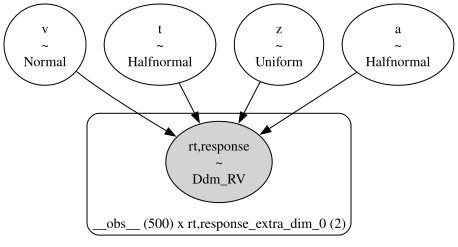

In [7]:
simple_ddm_model.graph()

The graph uses probabilistic-programming notation:

- white nodes are unknown random variables to estimate;
- the grey node is the observed choice/response-time data;
- rounded rectangles describe dimensions; and
- sharp-cornered rectangles denote deterministic quantities.

For simple models the graph is compact. The goal is not to memorize every node, but to check that the observed data, parameters, and deterministic transformations match your scientific story. The graph becomes especially helpful once regressions and participant-level effects are added.

#### Sample from the posterior

We now use PyMC's NUTS sampler to draw posterior samples. A posterior sample is a collection of plausible parameter values after combining the prior, the likelihood, and the observed data. The settings below are intentionally small so the tutorial remains runnable; increase chains, draws, and tuning for a real analysis.

In [8]:
infer_data_simple_ddm_model = quiet_call(
    simple_ddm_model.sample,
    sampler="pymc",
    cores=1,
    chains=N_CHAINS,
    draws=N_DRAWS,
    tune=N_TUNE,
    idata_kwargs=dict(log_likelihood=False),
    mp_ctx="spawn",
    progressbar=PYMC_PROGRESS,
    random_seed=SEEDS["simple"],
)

Sampling returns an `xarray.DataTree`: a labeled container for all the fitted-model results. Next, we will inspect its contents and use ArviZ to assess what the sampler returned.

In [9]:
type(infer_data_simple_ddm_model)

xarray.core.datatree.DataTree

#### Understand the fitted result

HSSM (via the ArviZ package) stores results in an `xarray.DataTree`. Each group contains a related part of the Bayesian workflow, such as posterior samples, pointwise log likelihoods, sampler statistics, or observed data.

You do not need to manipulate every group to use HSSM, but recognizing this structure makes it easier to use ArviZ and to add your own analyses. When you see later calls such as `az.summary(...)`, `az.plot_trace(...)`, or `az.compare(...)`, ArviZ is reading these labeled groups.

In [10]:
{
    "groups": tuple(infer_data_simple_ddm_model.children),
    "posterior_sizes": dict(infer_data_simple_ddm_model.posterior.ds.sizes),
}

{'groups': ('posterior', 'sample_stats', 'observed_data'),
 'posterior_sizes': {'chain': 2, 'draw': 500}}

For this model, the most important groups are:

- `posterior`: sampled values for model parameters such as `v`, `a`, `z`, and `t`;
- `sample_stats`: sampler diagnostics such as divergences, tree depth, and acceptance information;
- `observed_data`: the choices and response times that were modeled;
- `posterior_predictive`: simulated data from the fitted model, added later when we run posterior predictive checks.

This first fit omits `log_likelihood` to keep the tutorial fast. The three model-comparison fits later enable it because leave-one-out comparison needs trial-level likelihood contributions.

#### Work with posterior draws

##### Access groups and variables

In [11]:
tuple(infer_data_simple_ddm_model.posterior.ds.data_vars)

('v', 't', 'z', 'a')

In [12]:
np.round(infer_data_simple_ddm_model.posterior.a.values[0, :5], 3)

array([1.536, 1.46 , 1.444, 1.475, 1.491])

To simply access the underlying data as a `numpy.ndarray`, we can use `.values` (as e.g. when using `pandas.DataFrame` objects).

In [13]:
type(infer_data_simple_ddm_model.posterior.a.values)

numpy.ndarray

##### Combine chains and draws

Many follow-up calculations are easier when the `chain` and `draw` dimensions are combined into a single `sample` dimension. ArviZ's `extract` helper provides a convenient interface for this common operation. The following cell shows the equivalent lower-level `xarray` operation.

In [14]:
idata_extracted = az.extract(infer_data_simple_ddm_model)
{
    "variables": tuple(idata_extracted.data_vars),
    "sizes": dict(idata_extracted.sizes),
}

{'variables': ('v', 't', 'z', 'a'), 'sizes': {'sample': 1000}}

In [15]:
dict(infer_data_simple_ddm_model.posterior.ds.stack(sample=("chain", "draw")).sizes)

{'sample': 1000}

#### ArviZ for diagnostics and visualization

<div style="text-align: center;">
  <img src="images/arviz.png" alt="ArviZ logo" style="height: 120px; width: auto; max-width: 80%;">
</div>

HSSM returns `xarray`-based inference results that work directly with [ArviZ](https://python.arviz.org/en/stable/index.html). We will use ArviZ to summarize posterior uncertainty, inspect MCMC traces, check posterior predictions, and compare models. The examples below focus on the few summaries and plots that are most useful when starting out.

#### Diagnose and interpret the posterior

In [16]:
az.summary(
    infer_data_simple_ddm_model,
    var_names=[var_name.name for var_name in simple_ddm_model.pymc_model.free_RVs],
)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
t,0.536,0.032,0.48,0.59,608,580,1.00,0.0013,0.00097
z,0.517,0.02,0.49,0.55,587,528,1.00,0.00082,0.00056
a,1.499,0.038,1.4,1.6,609,445,1.00,0.0015,0.0011
v,0.49,0.049,0.41,0.57,583,655,1.00,0.002,0.0014


In [17]:
simple_health = compact_diagnostics(
    infer_data_simple_ddm_model,
    var_names=["v", "a", "z", "t"],
)
if FULL_RUN:
    assert simple_health["divergence_rate"] <= 0.005, (
        "core DDM divergence rate exceeds 0.5%"
    )
    assert simple_health["max_rhat"] <= 1.01, (
        f"core DDM max R-hat is {simple_health['max_rhat']:.4f}"
    )
    assert simple_health["min_bulk_or_tail_ess"] >= 200, (
        "core DDM minimum bulk/tail ESS is below 200"
    )
simple_health

{'scope': 'full diagnostic validation',
 'divergences': 0,
 'divergence_rate': 0.0,
 'max_rhat': 1.0045142345082707,
 'min_bulk_or_tail_ess': 445.7241865738978}

The summary reports posterior location and uncertainty for each parameter, plus diagnostics. The `mean` and `sd` columns describe the center and spread of the posterior draws. The highest-density interval (`hdi_3%` to `hdi_97%` by default) gives a compact uncertainty interval. Start diagnostics with `r_hat`: values near 1 indicate that independent chains explored the same distribution. As a practical rule, investigate values above 1.01 and inspect trace plots before interpreting parameter estimates.

##### Trace and distribution plots

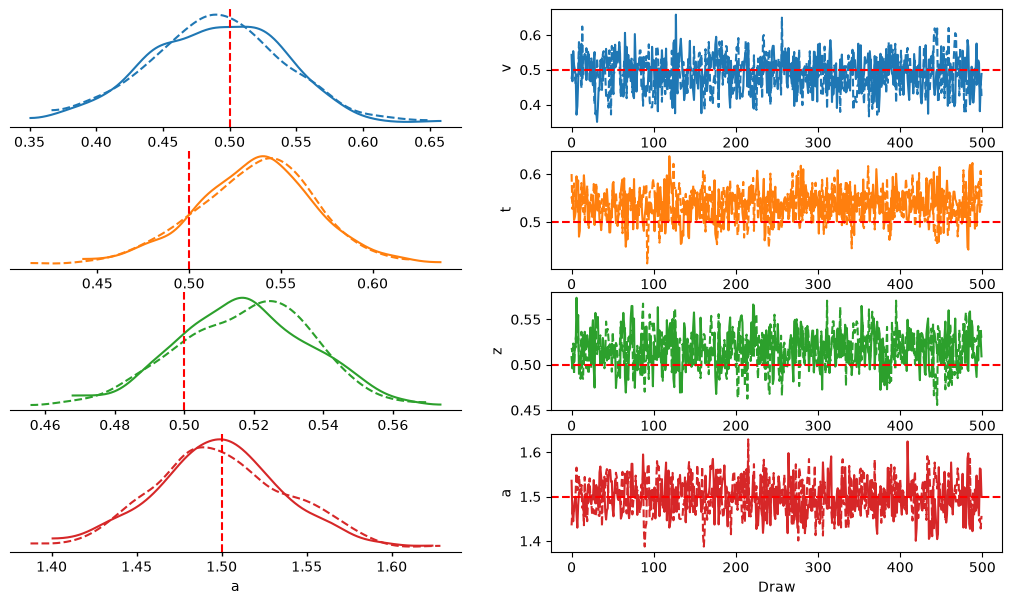

In [18]:
_pc = az.plot_trace_dist(infer_data_simple_ddm_model)
add_trace_reference_lines(_pc, param_dict_init)

HSSM also stores the latest result on `.traces`. Both access patterns are equivalent; this reactive notebook keeps using the explicitly returned result so every diagnostic has a visible dependency on sampling.

The distribution panel summarizes posterior uncertainty for each parameter. The MCMC trace panel shows each chain across draws; stable, overlapping chains suggest the sampler is repeatedly visiting the same high-probability region rather than getting stuck in different places. The red reference lines mark the known values used to simulate the data.

##### Forest plots

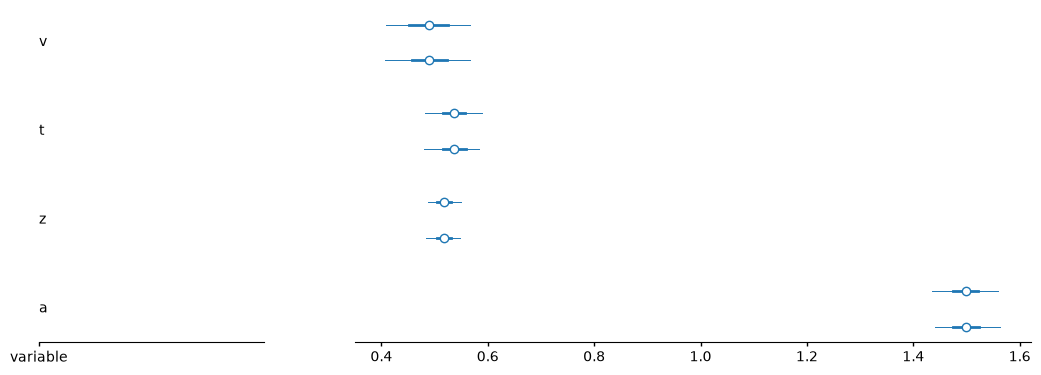

In [19]:
_ = az.plot_forest(infer_data_simple_ddm_model)

A forest plot turns posterior uncertainty into intervals, which is useful when many parameters or chains are shown at once. By default, chains are shown separately. Combining chains can make a large forest plot easier to scan once you have already checked trace diagnostics.

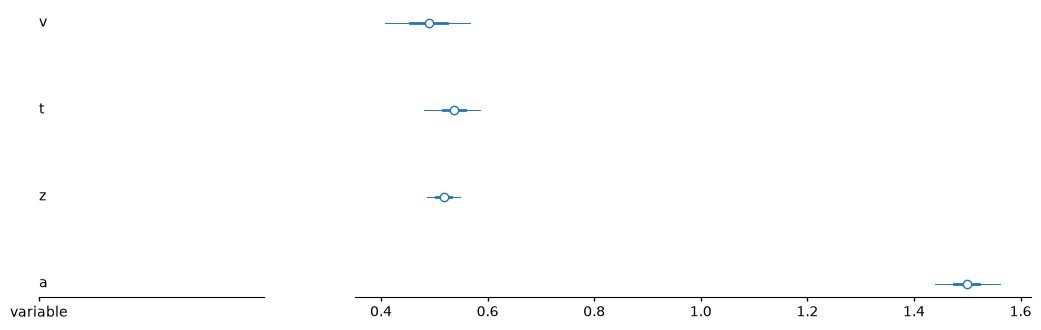

In [20]:
_ = az.plot_forest(infer_data_simple_ddm_model, combined=True)

##### Marginal posterior plots

A marginal posterior plot ignores sampling order and focuses on the distribution of one parameter at a time. Because this is simulated data, we can compare the posterior with the known generating values. The standalone marginal plot below uses vertical reference lines; the paired trace/distribution plots use vertical lines on distributions and horizontal lines on traces.

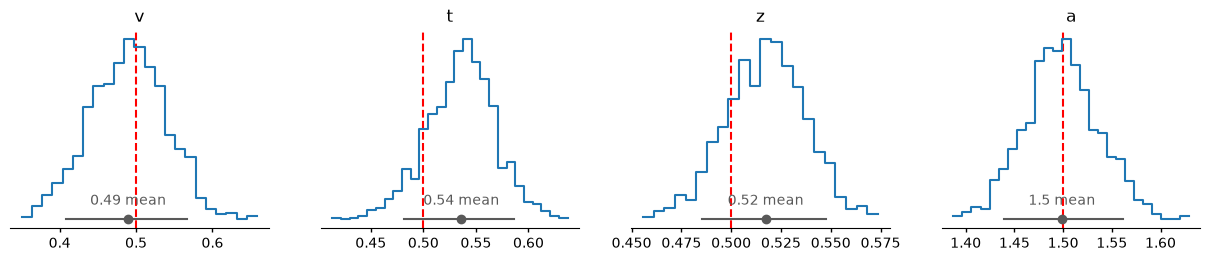

In [21]:
_pc = az.plot_dist(infer_data_simple_ddm_model, kind="hist")
_ = az.add_lines(
    _pc,
    values=param_dict_init,
    orientation="vertical",
    visuals={"ref_line": dict(color="red", linestyle="--")},
)

##### Posterior pair plots

Pair plots reveal relationships between posterior parameters. Strong trade-offs can signal weak identification: when one parameter increases, another may compensate while producing similar predicted behavior. This is common in cognitive models, where several parameters can affect the same response-time or choice pattern.

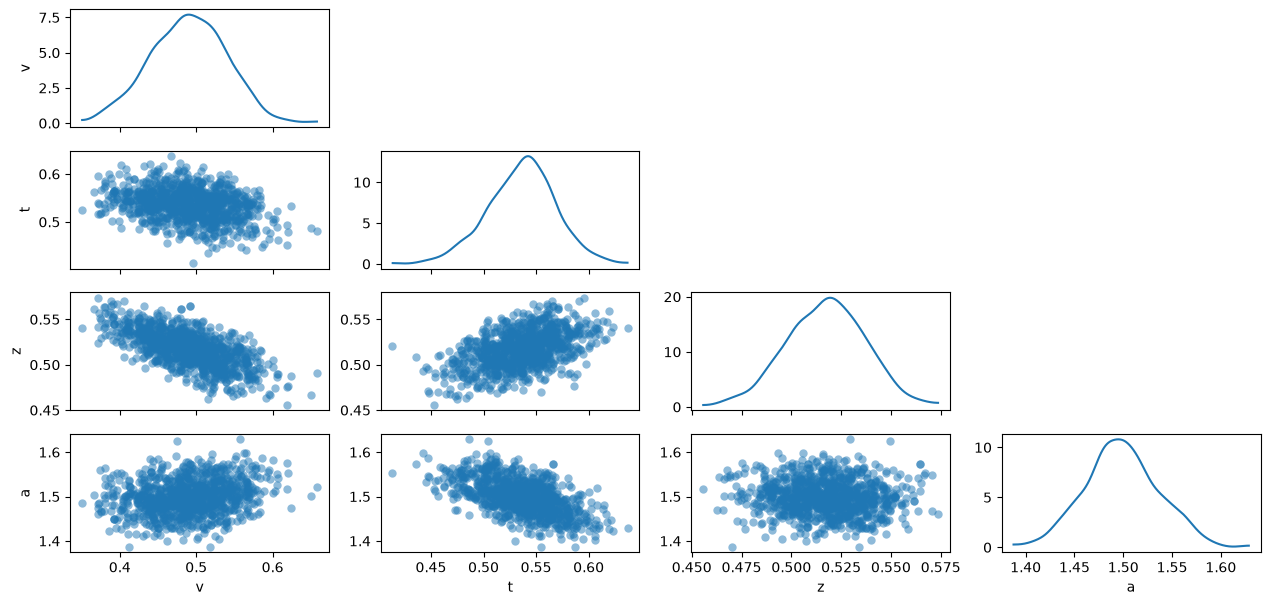

In [22]:
_ = az.plot_pair(infer_data_simple_ddm_model, marginal_kind="kde")

ArviZ provides many additional diagnostics and plotting tools. The [current user guide](https://python.arviz.org/en/stable/user_guide/getting_started.html) is the best next reference when you need a specific plot or diagnostic.

#### Compute quantities from posterior draws

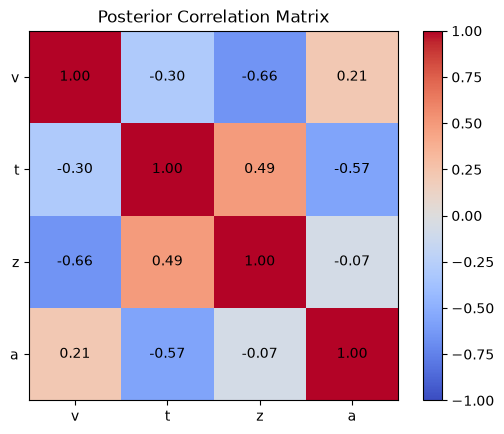

In [23]:
# Calculate the correlation matrix
posterior_correlation_matrix = np.corrcoef(
    np.stack(
        [
            idata_extracted[var_].values
            for var_ in idata_extracted.data_vars.variables
        ]
    )
)
num_vars = posterior_correlation_matrix.shape[0]
fig, ax = plt.subplots(1, 1)
cax = ax.imshow(posterior_correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
fig.colorbar(cax, ax=ax)
ax.set_title("Posterior Correlation Matrix")
ax.set_xticks(range(posterior_correlation_matrix.shape[0]))
# Make heatmap
ax.set_xticklabels([var_ for var_ in idata_extracted.data_vars.variables])
ax.set_yticks(range(posterior_correlation_matrix.shape[0]))
ax.set_yticklabels([var_ for var_ in idata_extracted.data_vars.variables])
for _i in range(num_vars):
    for j in range(num_vars):
        # Add ticks
        ax.text(
            j,
            _i,
            f"{posterior_correlation_matrix[_i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
        )
# Annotate heatmap
plt.show()

### Check posterior predictions

Good MCMC diagnostics show that the sampler explored the stated model reliably; they do not show that the model captures the data. Posterior predictive checks compare data simulated from the fitted model with the observations and are an essential step before substantive interpretation. In workflow terms, this is where we ask: if the fitted model were true, would it generate choices and response times that look like the data we actually observed?

In [24]:
ppc_idata = quiet_call(
    simple_ddm_model.sample_posterior_predictive,
    dt=infer_data_simple_ddm_model,
    draws=N_PPC_DRAWS,
    inplace=False,
)

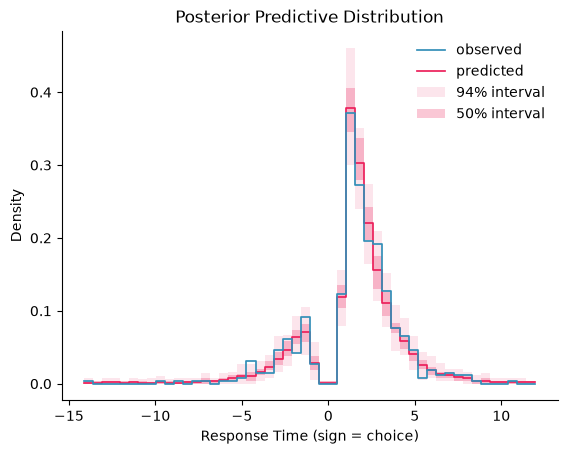

In [25]:
_ppc_axes = simple_ddm_model.plot_predictive(dt=ppc_idata)
_ppc_figure = _ppc_axes.figure
plt.close(_ppc_figure)
_ppc_figure

The posterior predictive call returns a result with a `posterior_predictive` group, and `plot_predictive()` visualizes those simulated datasets against the observations. If predictions reproduce the main features of the observed response-time and choice distributions, the model is a useful approximation for those features. Systematic mismatches suggest revisiting the likelihood, parameterization, covariates, or model family.

HSSM does not currently expose a random-seed argument for posterior predictive sampling. All data simulation and MCMC fits on this page are seeded; the exact predictive draws may vary while the same model check is performed.

## 2. Choose a model and likelihood

In [26]:
simple_ddm_model.loglik_kind

'analytical'

The DDM above used HSSM’s `analytical` likelihood. Other sequential-sampling models may instead use an `approx_differentiable` likelihood, such as a likelihood approximation network (LAN), or a user-supplied `blackbox` likelihood. The model interface stays similar; HSSM chooses compatible computational machinery behind the scenes.

### An angle model with collapsing boundaries

The `angle` model extends the DDM with `theta`, which controls the rate at which decision boundaries collapse over time.

<div style="text-align: center;">
  <img src="images/ANGLE_with_params_pic.png" alt="Angle model diagram with collapsing decision boundaries and theta parameter" style="width: 360px; max-width: 90%; height: auto;">
</div>

Collapsing boundaries are useful when urgency or time pressure may change a participant’s decision criterion. HSSM makes inference for these models practical through packaged `approx_differentiable` likelihoods.

In [27]:
# Simulate angle data
v_angle_true = 0.5
a_angle_true = 1.5
z_angle_true = 0.5
t_angle_true = 0.2
theta_angle_true = 0.2

param_dict_angle = dict(v=0.5, a=1.5, z=0.5, t=0.2, theta=0.2)

dataset_angle = hssm.simulate_data(
    model="angle",
    theta=param_dict_angle,
    size=N_ANGLE_TRIALS,
    random_state=SEEDS["angle"],
)

We pass a single additional argument to our `HSSM` class and set `model='angle'`.

In [28]:
model_angle = hssm.HSSM(
    data=dataset_angle, model="angle", initval_jitter=INITVAL_JITTER
)

model_angle

Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: angle

Response variable: rt,response
Likelihood: approx_differentiable
Observations: 1000

Parameters:

v:
    Prior: Uniform(lower: -3.0, upper: 3.0)
    Explicit bounds: (-3.0, 3.0)

a:
    Prior: Uniform(lower: 0.3, upper: 3.0)
    Explicit bounds: (0.3, 3.0)

z:
    Prior: Uniform(lower: 0.1, upper: 0.9)
    Explicit bounds: (0.1, 0.9)

t:
    Prior: Uniform(lower: 0.001, upper: 2.0)
    Explicit bounds: (0.001, 2.0)

theta:
    Prior: Uniform(lower: -0.1, upper: 1.3)
    Explicit bounds: (-0.1, 1.3)


Lapse probability: 0.05
Lapse distribution: Uniform(lower: 0.0, upper: 20.0)

The graph now includes the additional `theta` parameter. This is a quick way to confirm that the model specification matches the scientific question.

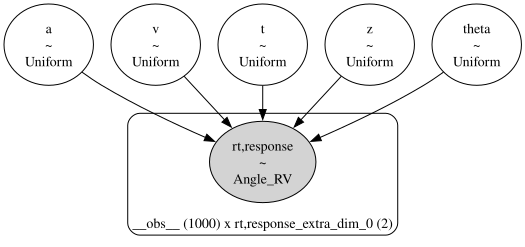

In [29]:
model_angle.graph()

Let's check the type of likelihood that is used under the hood ...

In [30]:
model_angle.loglik_kind

'approx_differentiable'

This model uses an `approx_differentiable` likelihood. In the packaged model collection, that typically means a LAN is used internally to approximate the likelihood.

In [31]:
jax.config.update("jax_enable_x64", False)
infer_data_angle = quiet_call(
    model_angle.sample,
    sampler="numpyro",
    chains=N_CHAINS,
    cores=1,
    draws=N_DRAWS,
    tune=N_TUNE,
    idata_kwargs=dict(log_likelihood=False),  # no need to return likelihoods here
    # mp_ctx="spawn",
    progressbar=EXTERNAL_PROGRESS,
    random_seed=SEEDS["angle"],
)

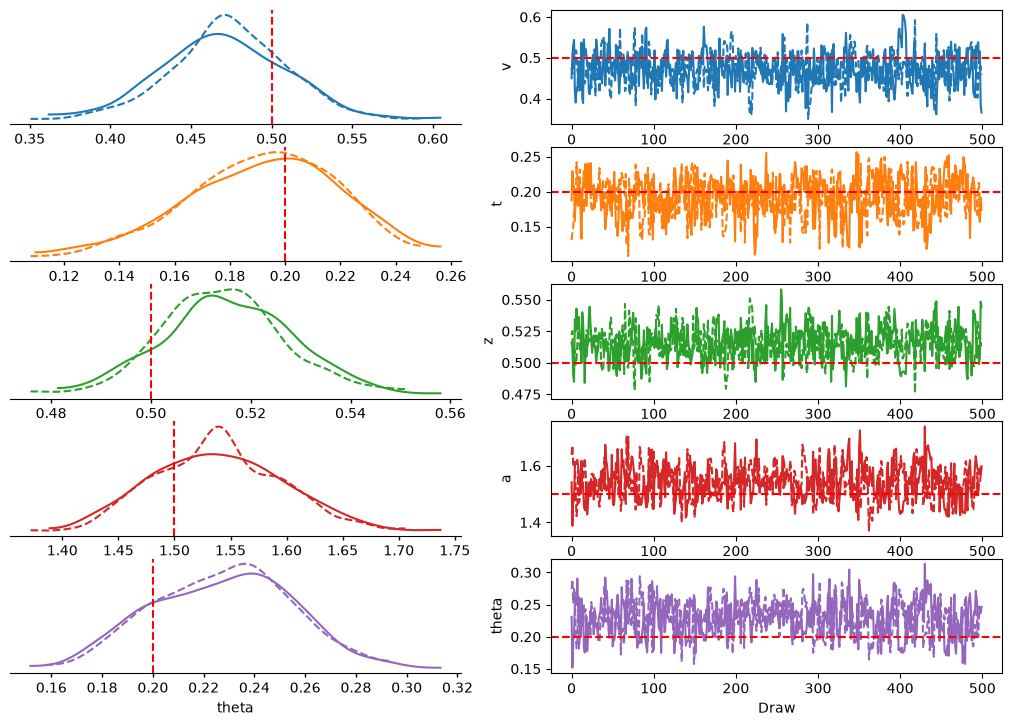

In [32]:
_pc = az.plot_trace_dist(infer_data_angle)
add_trace_reference_lines(_pc, param_dict_angle)

## 3. Customize priors and model structure

Priors express plausible parameter ranges before observing the data. HSSM supports defaults that respect model bounds, fixed values for parameters you do not want to estimate, and explicit PyMC distributions when you need stronger domain knowledge.

### Fix parameters when the design justifies it

Sometimes a parameter is fixed by design or is outside the present research question. Here we estimate only the drift rate `v` while holding the other DDM parameters fixed.

<div style="text-align: center;">
  <img src="images/DDM_only_v_pic.png" alt="Drift diffusion model diagram with only the drift-rate parameter v estimated" style="width: 360px; max-width: 90%; height: auto;">
</div>

Fixing parameters reduces model flexibility, so it should be justified by theory, design, or a deliberate comparison.

In [33]:
param_dict_init

{'v': 0.5, 'a': 1.5, 'z': 0.5, 't': 0.5}

In [34]:
ddm_model_only_v = hssm.HSSM(
    data=dataset,
    model="ddm",
    a=param_dict_init["a"],
    t=param_dict_init["t"],
    z=param_dict_init["z"],
    initval_jitter=INITVAL_JITTER,
)

Model initialized successfully.


Since we fix all but one parameter, we estimate only one parameter. This is a useful pattern when a parameter is known from design, when a previous analysis justifies a fixed value, or when you want to isolate one cognitive process. The model graph should reflect this choice: we expect only one free random variable, `v`.

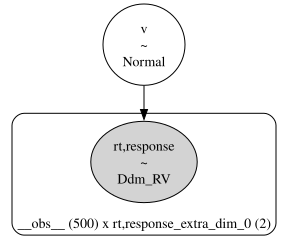

In [35]:
ddm_model_only_v.graph()

In [36]:
infer_data_only_v = quiet_call(
    ddm_model_only_v.sample,
    sampler="pymc",
    chains=N_CHAINS,
    cores=1,
    draws=N_PRIMARY_REG_DRAWS,
    tune=N_PRIMARY_REG_TUNE,
    idata_kwargs=dict(log_likelihood=False),  # no need to return likelihoods here
    mp_ctx="spawn",
    progressbar=PYMC_PROGRESS,
    random_seed=SEEDS["only_v"],
)

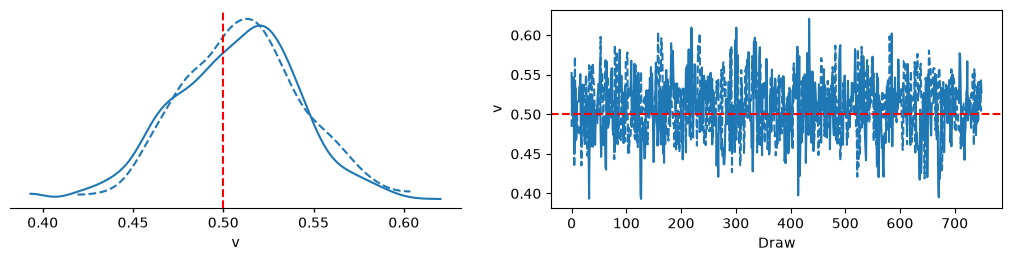

In [37]:
_pc = az.plot_trace_dist(infer_data_only_v)
add_trace_reference_lines(_pc, {"v": param_dict_init["v"]})

A rank plot complements a trace plot by checking whether chains are sampling from the same distribution. Roughly uniform ranks across chains are consistent with good mixing; visible chain-specific patterns call for further diagnosis.

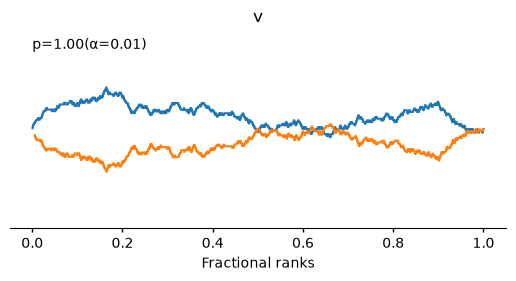

In [38]:
if FULL_RUN:
    _ = az.plot_rank(infer_data_only_v)
else:
    print("Rank diagnostics require the two-chain full run.")

### Specify informative priors

In [39]:
model_normal = hssm.HSSM(
    data=dataset,
    include=[
        {
            "name": "v",
            "prior": {"name": "Normal", "mu": 0, "sigma": 0.01},
        }
    ],
    initval_jitter=INITVAL_JITTER,
)

Model initialized successfully.


In [40]:
model_normal

Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 500

Parameters:

v:
    Prior: Normal(mu: 0.0, sigma: 0.01)
    Explicit bounds: (-inf, inf)

a:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)

z:
    Prior: Uniform(lower: 0.0, upper: 1.0)
    Explicit bounds: (0.0, 1.0)

t:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)


Lapse probability: 0.05
Lapse distribution: Uniform(lower: 0.0, upper: 20.0)

In [41]:
infer_data_normal = quiet_call(
    model_normal.sample,
    sampler="pymc",
    chains=N_CHAINS,
    cores=1,
    draws=N_DRAWS,
    tune=N_TUNE,
    idata_kwargs=dict(log_likelihood=False),  # no need to return likelihoods here
    mp_ctx="spawn",
    progressbar=PYMC_PROGRESS,
    random_seed=SEEDS["bad_prior"],
)

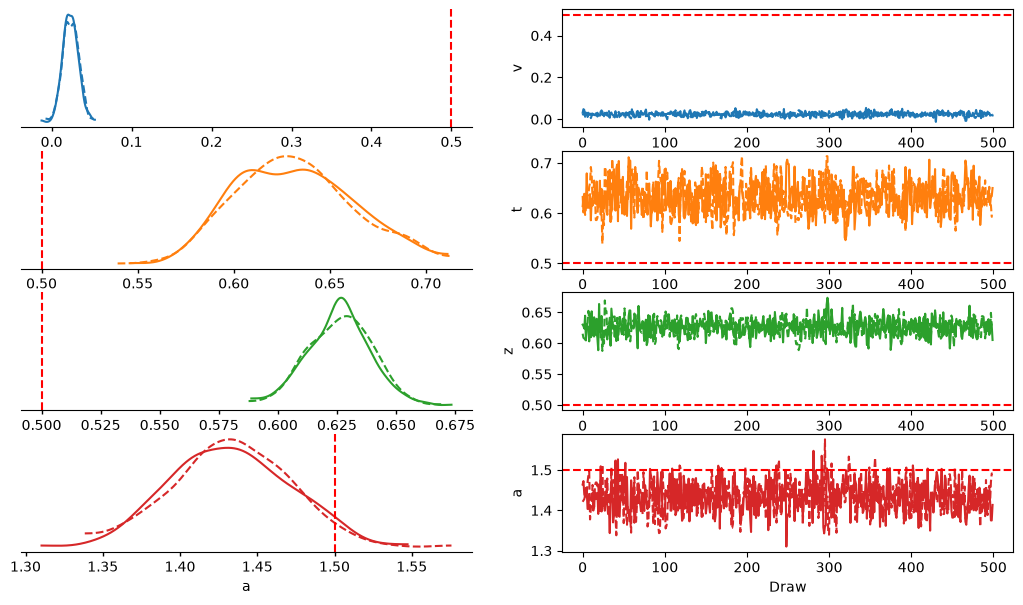

In [42]:
_pc = az.plot_trace_dist(infer_data_normal)
add_trace_reference_lines(_pc, param_dict_init)

In [43]:
narrow_prior_health = compact_diagnostics(
    infer_data_normal,
    var_names=["v", "a", "z", "t"],
)
narrow_prior_health

{'scope': 'full diagnostic validation',
 'divergences': 0,
 'divergence_rate': 0.0,
 'max_rhat': 1.0040575947231443,
 'min_bulk_or_tail_ess': 600.7104172477327}

The data were generated with `v=0.5`, `a=1.5`, `z=0.5`, and `t=0.5`. Compare the trace and compact diagnostic snapshot with the baseline fit. If the narrow prior pulls `v` toward zero, other parameters may compensate; any divergences or weak diagnostics are reasons not to interpret this intentionally restrictive fit. This example is reported, not gated, because it is designed to illustrate a problematic prior.

### Regressions on cognitive parameters

<div style="text-align: center;">
  <img src="images/bambi.png" alt="Bambi logo" style="height: 120px; width: auto; max-width: 80%;">
</div>

HSSM can link individual SSM parameters to trial-level covariates with Bambi-style formulas. This lets you ask questions such as whether a neural signal, condition, or behavioral measure predicts drift rate, boundary separation, or bias.

#### One parameter as a regression target

#### Simulating Data

We simulate data in which drift rate varies with two trial-level covariates. The known coefficients give us a clear recovery target.

In [44]:
# Set up trial by trial parameters
_rng = np.random.default_rng(SEEDS["reg"])
v_intercept = 0.3
x = _rng.uniform(-1, 1, size=N_REG_TRIALS)
v_x = 0.8
y = _rng.uniform(-1, 1, size=N_REG_TRIALS)
v_y = 0.3
_v_reg_v = v_intercept + v_x * x + v_y * y
_a_reg_v = 1.5
# rest
_z_reg_v = 0.5
_t_reg_v = 0.1
param_dict_reg_v = dict(
    a=1.5,
    z=0.5,
    t=0.1,
    v=_v_reg_v,
    v_x=v_x,
    v_y=v_y,
    v_Intercept=v_intercept,
    theta=0.0,
)
dataset_reg_v = hssm.simulate_data(
    model="ddm",
    theta=param_dict_reg_v,
    size=1,
    random_state=SEEDS["reg"],
)
dataset_reg_v["x"] = x
# base dataset
# Adding covariates into the datsaframe
dataset_reg_v["y"] = y

##### Define the regression

The `include` argument contains one specification per parameter with a regression. Each specification names the parameter, supplies a formula and link, and can define priors for regression coefficients.

Formula syntax follows Bambi and familiar R-style mixed-model notation. HSSM uses Bambi to translate these formulas into a PyMC model. Conceptually, this means the SSM parameter is no longer a single value; it can vary systematically with trial-level or participant-level predictors.

In [45]:
model_reg_v_simple = hssm.HSSM(
    data=dataset_reg_v,
    include=[{"name": "v", "formula": "v ~ 1 + x + y"}],
    initval_jitter=INITVAL_JITTER,
)

Model initialized successfully.


##### `Param` class
As illustrated below, there is an alternative way of specifying the parameter specific data via the `Param` class.

In [46]:
model_reg_v_simple_new = hssm.HSSM(
    data=dataset_reg_v,
    include=[hssm.Param(name="v", formula="v ~ 1 + x + y")],
    initval_jitter=INITVAL_JITTER,
)

Model initialized successfully.


In [47]:
{
    "dict_specification_free_RVs": tuple(
        rv.name for rv in model_reg_v_simple.pymc_model.free_RVs
    ),
    "Param_specification_free_RVs": tuple(
        rv.name for rv in model_reg_v_simple_new.pymc_model.free_RVs
    ),
}

{'dict_specification_free_RVs': ('t', 'z', 'a', 'v_Intercept', 'v_x', 'v_y'),
 'Param_specification_free_RVs': ('t', 'z', 'a', 'v_Intercept', 'v_x', 'v_y')}

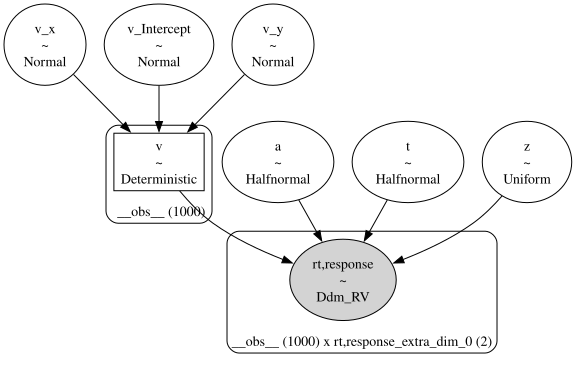

In [48]:
model_reg_v_simple.graph()

##### Customize parameter-specific priors

The default regression specification is often a good starting point. When prior knowledge is available, specify coefficient-level priors explicitly and then verify the resulting model summary before sampling.

In [49]:
model_reg_v = hssm.HSSM(
    data=dataset_reg_v,
    include=[
        {
            "name": "v",
            "prior": {
                "Intercept": {"name": "Uniform", "lower": -3.0, "upper": 3.0},
                "x": {"name": "Uniform", "lower": -1.0, "upper": 1.0},
                "y": {"name": "Uniform", "lower": -1.0, "upper": 1.0},
            },
            "formula": "v ~ 1 + x + y",
            "link": "identity",
        }
    ],
    initval_jitter=INITVAL_JITTER,
)

Model initialized successfully.


In [50]:
model_reg_v

Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 1000

Parameters:

v:
    Formula: v ~ 1 + x + y
    Priors:
        v_Intercept ~ Uniform(lower: -3.0, upper: 3.0)
        v_x ~ Uniform(lower: -1.0, upper: 1.0)
        v_y ~ Uniform(lower: -1.0, upper: 1.0)
    Link: identity
    Explicit bounds: (-inf, inf)

a:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)

z:
    Prior: Uniform(lower: 0.0, upper: 1.0)
    Explicit bounds: (0.0, 1.0)

t:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)


Lapse probability: 0.05
Lapse distribution: Uniform(lower: 0.0, upper: 20.0)

The model summary now shows `v` as a regression with an intercept and covariate coefficients. This is the same specification-check step as before, but now the summary should also confirm that the intended predictors entered the model.

In [51]:
infer_data_reg_v = quiet_call(
    model_reg_v.sample,
    sampler="pymc",
    chains=N_CHAINS,
    cores=1,
    draws=N_PRIMARY_REG_DRAWS,
    tune=N_PRIMARY_REG_TUNE,
    idata_kwargs={"log_likelihood": False},
    mp_ctx="spawn",
    progressbar=PYMC_PROGRESS,
    random_seed=SEEDS["reg"],
)

In [52]:
az.summary(infer_data_reg_v, var_names=["~a", "~z", "~t"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v_x,0.854,0.048,0.77,0.93,933,662,1.00,0.0016,0.0011
v_Intercept,0.322,0.033,0.27,0.37,1243,1137,1.00,0.00093,0.00066
v_y,0.369,0.046,0.3,0.44,1430,1049,1.00,0.0012,0.00086


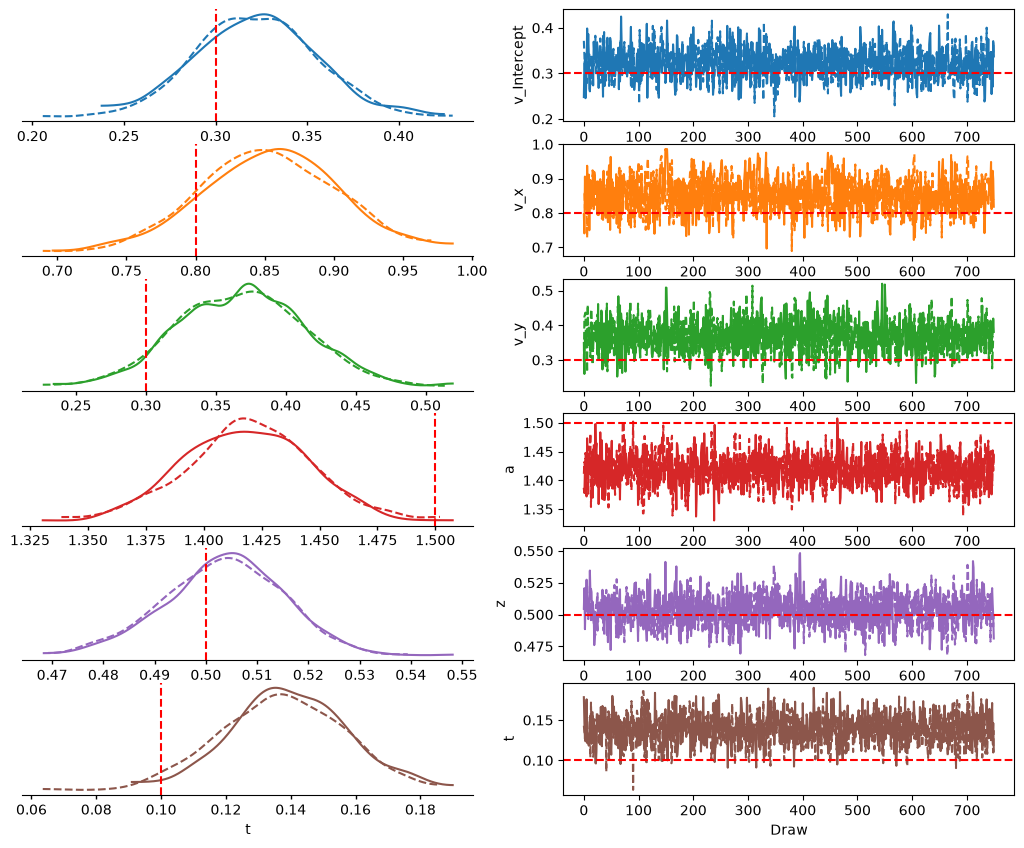

In [53]:
_pc = az.plot_trace_dist(
    infer_data_reg_v,
    var_names=["v_Intercept", "v_x", "v_y", "a", "z", "t"],
)
add_trace_reference_lines(_pc, param_dict_reg_v)

In [54]:
regression_health = compact_diagnostics(
    infer_data_reg_v,
    var_names=["v_Intercept", "v_x", "v_y", "a", "z", "t"],
)
recovery_report = {}
raw_hdis = {}
probabilities_positive = {}
for _name in ("v_Intercept", "v_x", "v_y"):
    _draws = az.extract(infer_data_reg_v, var_names=[_name]).values
    _hdi = az.hdi(_draws, prob=0.94)
    raw_hdis[_name] = _hdi
    probabilities_positive[_name] = float((_draws > 0).mean())
    recovery_report[_name] = {
        "known_value": param_dict_reg_v[_name],
        "posterior_mean": round(float(_draws.mean()), 3),
        "94%_HDI": tuple(round(float(value), 3) for value in _hdi),
        "P(>0)": round(probabilities_positive[_name], 3),
    }
if FULL_RUN:
    assert regression_health["divergence_rate"] <= 0.005, (
        "primary regression divergence rate exceeds 0.5%"
    )
    assert regression_health["max_rhat"] <= 1.01, (
        f"primary regression max R-hat is {regression_health['max_rhat']:.4f}"
    )
    assert regression_health["min_bulk_or_tail_ess"] >= 200, (
        "primary regression minimum bulk/tail ESS is below 200"
    )
    _v_x_hdi = raw_hdis["v_x"]
    assert _v_x_hdi[0] <= param_dict_reg_v["v_x"] <= _v_x_hdi[1], (
        "primary regression HDI misses the known focal v_x effect"
    )
    assert probabilities_positive["v_x"] >= 0.95, (
        "primary regression does not clearly support a positive v_x effect"
    )
{"diagnostics": regression_health, "coefficient_recovery": recovery_report}

{'diagnostics': {'scope': 'full diagnostic validation',
  'divergences': 0,
  'divergence_rate': 0.0,
  'max_rhat': 1.0032001092951146,
  'min_bulk_or_tail_ess': 662.3553795743202},
 'coefficient_recovery': {'v_Intercept': {'known_value': 0.3,
   'posterior_mean': 0.322,
   '94%_HDI': (0.26, 0.383),
   'P(>0)': 1.0},
  'v_x': {'known_value': 0.8,
   'posterior_mean': 0.854,
   '94%_HDI': (0.757, 0.941),
   'P(>0)': 1.0},
  'v_y': {'known_value': 0.3,
   'posterior_mean': 0.369,
   '94%_HDI': (0.279, 0.452),
   'P(>0)': 1.0}}}

The full publication run requires acceptable diagnostics and checks that the 94% interval for the focal `v_x` coefficient contains its known value (`0.8`) with high posterior probability above zero. The intercept and `v_y` estimates are reported without simultaneous-coverage assertions; inspect their uncertainty rather than treating every finite simulation as exact recovery.

#### Regression with an angle model

In [55]:
model_reg_v_angle = hssm.HSSM(
    data=dataset_reg_v,
    model="angle",
    include=[
        {
            "name": "v",
            "prior": {
                "Intercept": {
                    "name": "Uniform",
                    "lower": -3.0,
                    "upper": 3.0,
                },
                "x": {
                    "name": "Uniform",
                    "lower": -1.0,
                    "upper": 1.0,
                },
                "y": {"name": "Uniform", "lower": -1.0, "upper": 1.0},
            },
            "formula": "v ~ 1 + x + y",
            "link": "identity",
        }
    ],
    initval_jitter=INITVAL_JITTER,
)

Model initialized successfully.


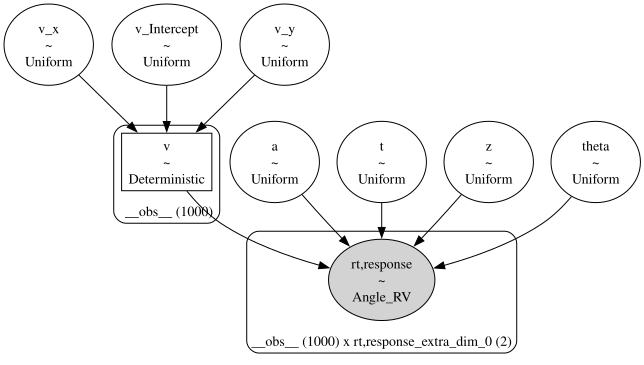

In [56]:
model_reg_v_angle.graph()

In [57]:
trace_reg_v_angle = quiet_call(
    model_reg_v_angle.sample,
    sampler="pymc",
    chains=N_CHAINS,
    cores=1,
    draws=N_DRAWS,
    tune=N_TUNE,
    idata_kwargs={"log_likelihood": False},
    mp_ctx="spawn",
    progressbar=PYMC_PROGRESS,
    random_seed=SEEDS["reg_angle"],
)

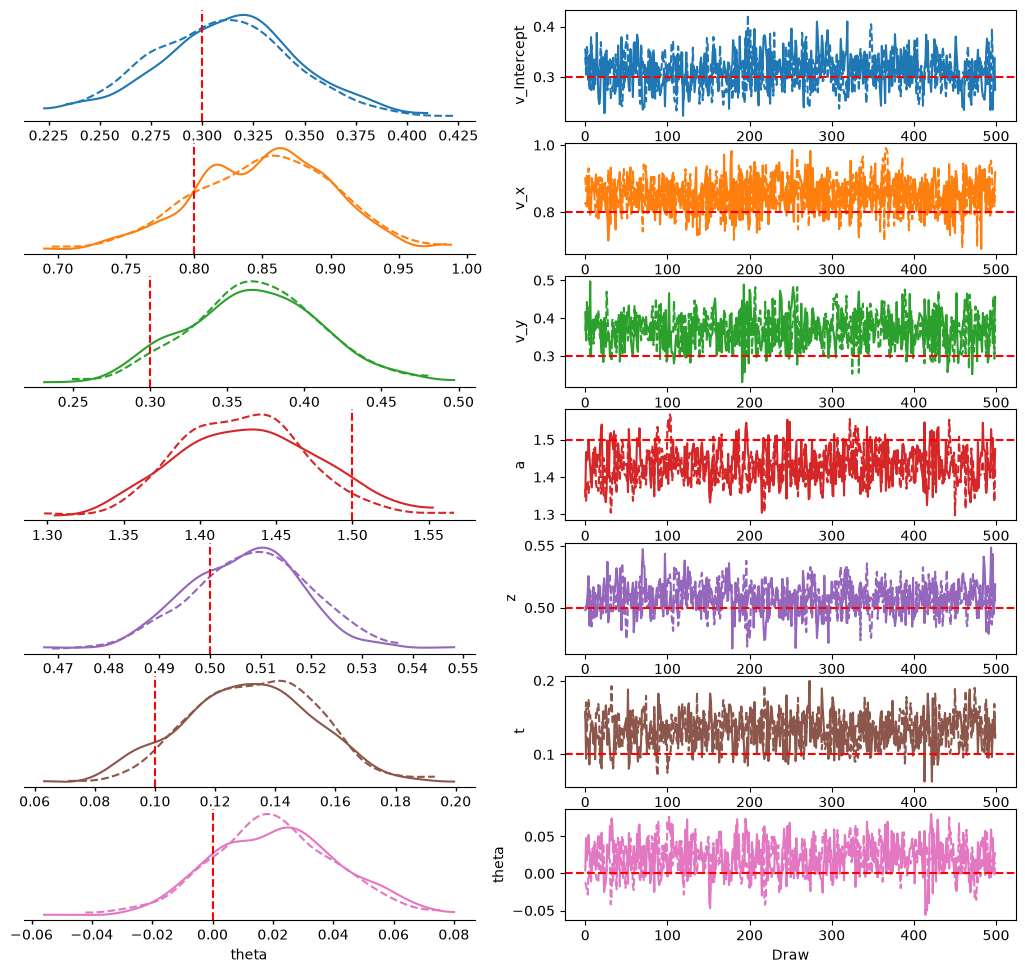

In [58]:
_pc = az.plot_trace_dist(
    trace_reg_v_angle,
    var_names=["v_Intercept", "v_x", "v_y", "a", "z", "t", "theta"],
)
add_trace_reference_lines(_pc, param_dict_reg_v)

Inspect the posterior interval for `theta`: data generated by a standard DDM support the expected story only when that interval is compatible with zero and the sampler diagnostics are acceptable. Interpret the remaining parameters with the same conditional workflow.

#### Regress multiple parameters

We now fit regressions for both `v` and `a`. Only `v` truly varies with the simulated covariates, so the `a` coefficients should be centered near zero.

In [59]:
# Instantiate our hssm model
from copy import deepcopy

param_dict_reg_v_a = deepcopy(param_dict_reg_v)
param_dict_reg_v_a["a_Intercept"] = param_dict_reg_v_a["a"]
param_dict_reg_v_a["a_x"] = 0
param_dict_reg_v_a["a_y"] = 0

hssm_reg_v_a_angle = hssm.HSSM(
    data=dataset_reg_v,
    model="angle",
    include=[
        {
            "name": "v",
            "prior": {
                "Intercept": {"name": "Uniform", "lower": -3.0, "upper": 3.0},
                "x": {"name": "Uniform", "lower": -1.0, "upper": 1.0},
                "y": {"name": "Uniform", "lower": -1.0, "upper": 1.0},
            },
            "formula": "v ~ 1 + x + y",
        },
        {
            "name": "a",
            "prior": {
                "Intercept": {"name": "Uniform", "lower": 0.5, "upper": 3.0},
                "x": {"name": "Uniform", "lower": -1.0, "upper": 1.0},
                "y": {"name": "Uniform", "lower": -1.0, "upper": 1.0},
            },
            "formula": "a ~ 1 + x + y",
        },
    ],
    initval_jitter=INITVAL_JITTER,
)

Model initialized successfully.


In [60]:
hssm_reg_v_a_angle

Hierarchical Sequential Sampling Model
Model: angle

Response variable: rt,response
Likelihood: approx_differentiable
Observations: 1000

Parameters:

v:
    Formula: v ~ 1 + x + y
    Priors:
        v_Intercept ~ Uniform(lower: -3.0, upper: 3.0)
        v_x ~ Uniform(lower: -1.0, upper: 1.0)
        v_y ~ Uniform(lower: -1.0, upper: 1.0)
    Link: identity
    Explicit bounds: (-3.0, 3.0)

a:
    Formula: a ~ 1 + x + y
    Priors:
        a_Intercept ~ Uniform(lower: 0.5, upper: 3.0)
        a_x ~ Uniform(lower: -1.0, upper: 1.0)
        a_y ~ Uniform(lower: -1.0, upper: 1.0)
    Link: identity
    Explicit bounds: (0.3, 3.0)

z:
    Prior: Uniform(lower: 0.1, upper: 0.9)
    Explicit bounds: (0.1, 0.9)

t:
    Prior: Uniform(lower: 0.001, upper: 2.0)
    Explicit bounds: (0.001, 2.0)

theta:
    Prior: Uniform(lower: -0.1, upper: 1.3)
    Explicit bounds: (-0.1, 1.3)


Lapse probability: 0.05
Lapse distribution: Uniform(lower: 0.0, upper: 20.0)

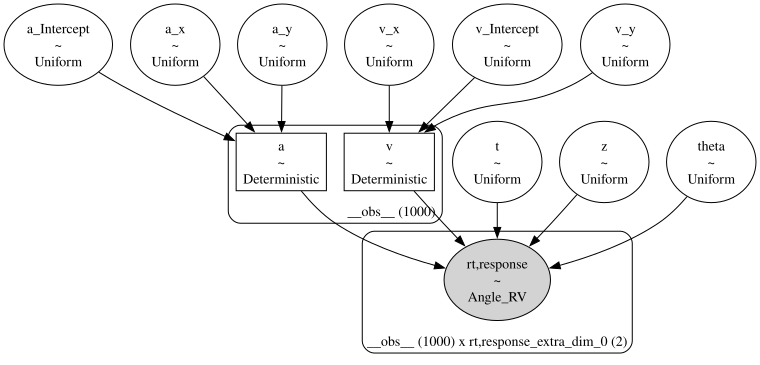

In [61]:
hssm_reg_v_a_angle.graph()

In [62]:
infer_data_reg_v_a = quiet_call(
    hssm_reg_v_a_angle.sample,
    sampler="pymc",
    chains=N_CHAINS,
    cores=1,
    draws=N_DRAWS,
    tune=N_TUNE,
    idata_kwargs={"log_likelihood": False},
    mp_ctx="spawn",
    progressbar=PYMC_PROGRESS,
    random_seed=SEEDS["reg_multi"],
)

In [63]:
az.summary(
    infer_data_reg_v_a,
    var_names=[
        "v_Intercept",
        "v_x",
        "v_y",
        "a_Intercept",
        "a_x",
        "a_y",
        "z",
        "t",
        "theta",
    ],
)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v_Intercept,0.316,0.033,0.26,0.37,833,760,1.00,0.0012,0.00078
v_x,0.856,0.052,0.77,0.94,631,314,1.00,0.002,0.0014
v_y,0.363,0.046,0.29,0.43,1208,887,1.00,0.0013,0.00095
a_Intercept,1.441,0.046,1.4,1.5,561,612,1.01,0.0019,0.0014
a_x,0.017,0.037,-0.044,0.078,1091,843,1.00,0.0011,0.0008
a_y,-0.023,0.037,-0.081,0.034,1234,871,1.00,0.001,0.00081
z,0.5063,0.012,0.49,0.52,836,670,1.00,0.00042,0.00028
t,0.128,0.023,0.088,0.16,623,648,1.00,0.00094,0.00069
theta,0.023,0.021,-0.011,0.056,521,614,1.01,0.00092,0.00067


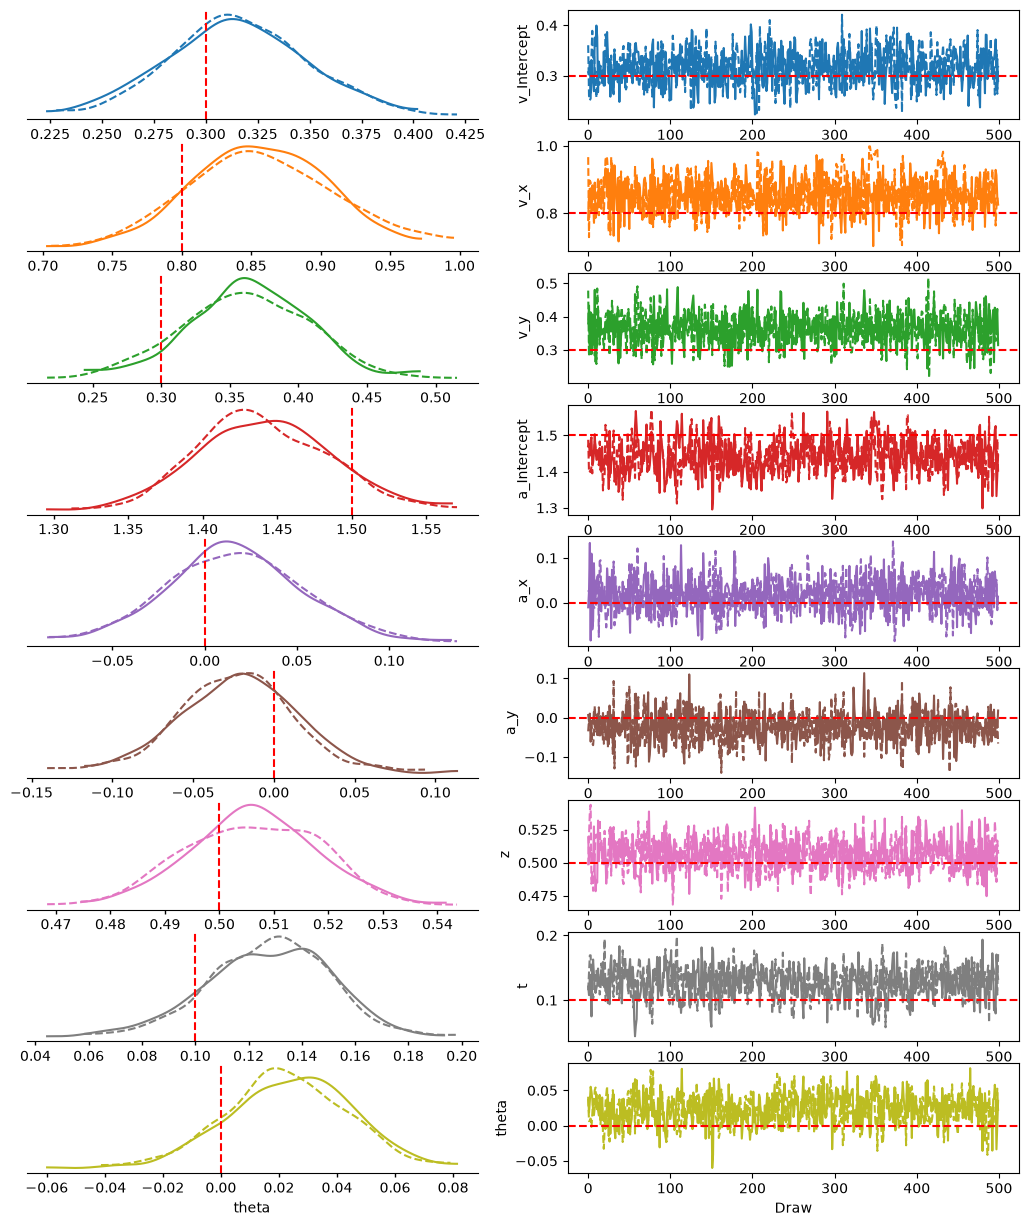

In [64]:
_pc = az.plot_trace_dist(
    infer_data_reg_v_a,
    var_names=[
        "v_Intercept",
        "v_x",
        "v_y",
        "a_Intercept",
        "a_x",
        "a_y",
        "z",
        "t",
        "theta",
    ],
)
add_trace_reference_lines(_pc, param_dict_reg_v_a)

Use the numeric summary to assess recovery: the `v` rows should be compared with their known coefficients, while the `a_x` and `a_y` intervals should be checked for compatibility with zero because the data-generating process did not vary `a` with these covariates. Treat either pattern as evidence from this finite run, not a guaranteed outcome.

#### Categorical covariates

In [65]:
_rng = np.random.default_rng(SEEDS["categorical"])
x_1 = _rng.choice(4, size=N_REG_TRIALS).astype(int)
x_offset = np.array([0, 1, -0.5, 0.75])
y_1 = _rng.uniform(-1, 1, size=N_REG_TRIALS)
v_y_1 = 0.3
_v_reg_v = 0 + v_y_1 * y_1 + x_offset[x_1]
_a_reg_v = 1.5
_z_reg_v = 0.5
_t_reg_v = 0.1
dataset_reg_v_cat = hssm.simulate_data(
    model="ddm",
    theta=dict(v=_v_reg_v, a=_a_reg_v, z=_z_reg_v, t=_t_reg_v),
    size=1,
    random_state=SEEDS["categorical"],
)
dataset_reg_v_cat["x"] = x_1
dataset_reg_v_cat["y"] = y_1

In [66]:
model_reg_v_cat = hssm.HSSM(
    data=dataset_reg_v_cat,
    model="angle",
    include=[
        {
            "name": "v",
            "formula": "v ~ 0 + C(x) + y",
            "link": "identity",
        }
    ],
    initval_jitter=INITVAL_JITTER,
)

Model initialized successfully.


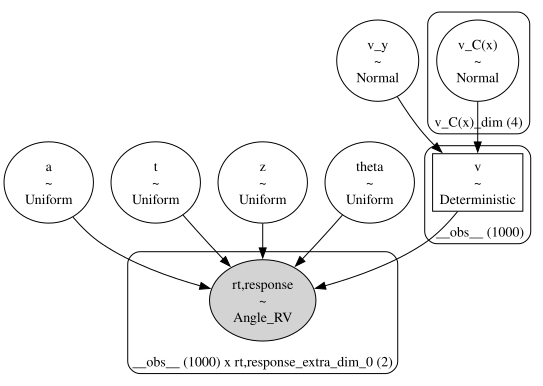

In [67]:
model_reg_v_cat.graph()

In [68]:
infer_data_reg_v_cat = quiet_call(
    model_reg_v_cat.sample,
    sampler="pymc",
    chains=N_CHAINS,
    cores=1,
    draws=N_DRAWS,
    tune=N_TUNE,
    idata_kwargs={"log_likelihood": False},
    mp_ctx="spawn",
    progressbar=PYMC_PROGRESS,
    random_seed=SEEDS["categorical"],
)

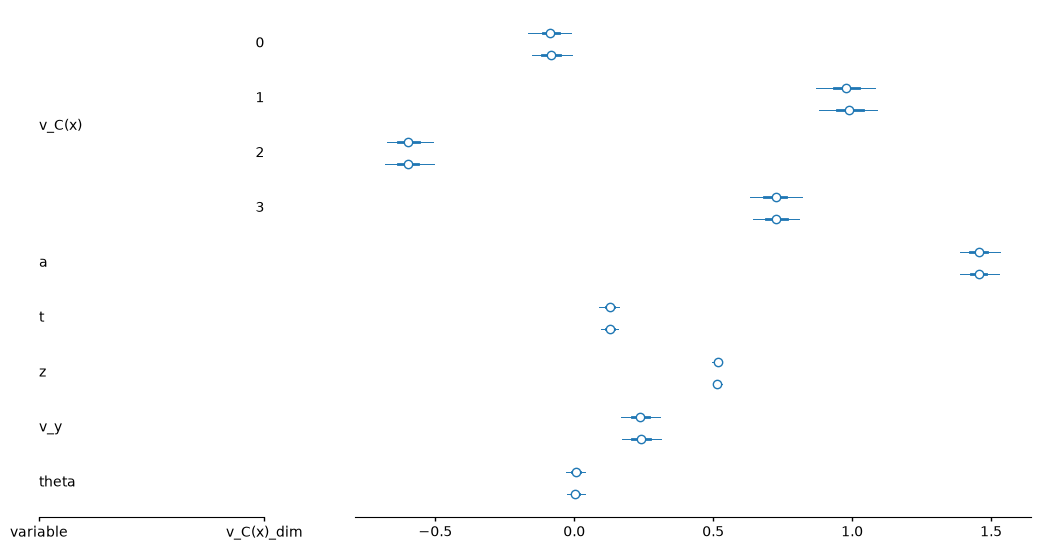

In [69]:
_ = az.plot_forest(infer_data_reg_v_cat)

### Hierarchical participant effects

Next we simulate data from 15 participants, each with 200 trials. A hierarchy lets participant-level estimates share information through a group distribution while preserving individual differences.

### Simulate Data

In [70]:
_rng = np.random.default_rng(SEEDS["hier"])
n_participants = N_HIER_PARTICIPANTS
n_trials = N_HIER_TRIALS
sd_v = 0.5
mean_v = 0.5
data_list = []
for _i in range(n_participants):
    v_intercept_hier = _rng.normal(mean_v, sd_v, size=1)
    x_2 = _rng.uniform(-1, 1, size=n_trials)
    v_x_hier = 0.8
    y_2 = _rng.uniform(-1, 1, size=n_trials)
    v_y_hier = 0.3
    v_hier = v_intercept_hier + v_x_hier * x_2 + v_y_hier * y_2
    a_hier = 1.5
    t_hier = 0.5
    z_hier = 0.5
    data_tmp = hssm.simulate_data(
        model="ddm",
        theta=dict(v=v_hier, a=a_hier, z=z_hier, t=t_hier),
        size=1,
        random_state=SEEDS["hier"] + _i,
    )
    data_tmp["participant_id"] = _i
    data_tmp["x"] = x_2
    data_tmp["y"] = y_2
    data_list.append(data_tmp)
dataset_reg_v_hier = pd.concat(data_list)
dataset_reg_v_hier

,rt,response,participant_id,x,y
0,1.804934,-1.0,0,-0.785018,0.792162
1,3.947494,1.0,0,0.295662,-0.817377
2,1.259359,1.0,0,0.921396,0.082609
3,1.769029,1.0,0,0.540598,0.916793
4,3.031497,1.0,0,0.816505,-0.200228
...,...,...,...,...,...
195,1.701335,1.0,14,0.269187,0.508749
196,4.755053,1.0,14,0.573819,0.963991
197,1.670578,1.0,14,0.427159,-0.728222
198,0.943260,-1.0,14,-0.029444,0.833860


We use `v ~ 1 + (1|participant_id) + x + y`. The random-intercept term `(1|participant_id)` gives each participant an offset around the group intercept; the remaining coefficients are shared across participants. The hierarchy lets participants borrow strength from the group while still allowing individual differences.

### Basic Hierarchical Model

Note the `noncentered=True` argument below: it selects the non-centered parameterization for the group-specific terms. The default is the right choice here — when and why to flip it (globally, or per parameter) is covered in [Centered vs. non-centered parameterizations](https://lnccbrown.github.io/HSSM/tutorials/centered_vs_noncentered_basic_logic/) and [Per-parameter parameterization](https://lnccbrown.github.io/HSSM/tutorials/parameterization_per_parameter/).

In [71]:
model_reg_v_angle_hier = hssm.HSSM(
    data=dataset_reg_v_hier,
    model="angle",
    noncentered=True,
    initval_jitter=INITVAL_JITTER,
    include=[
        {
            "name": "v",
            "prior": {
                "Intercept": {
                    "name": "Normal",
                    "mu": 0.0,
                    "sigma": 0.5,
                },
                "x": {"name": "Normal", "mu": 0.0, "sigma": 0.5},
                "y": {"name": "Normal", "mu": 0.0, "sigma": 0.5},
            },
            "formula": "v ~ 1 + (1|participant_id) + x + y",
            "link": "identity",
        }
    ],
)

Model initialized successfully.


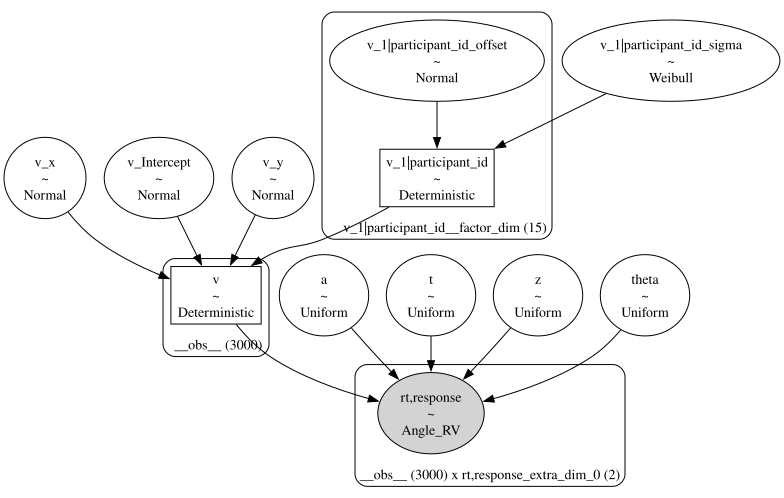

In [72]:
model_reg_v_angle_hier.graph()

In [73]:
jax.config.update("jax_enable_x64", False)
infer_data_reg_v_angle_hier = quiet_call(
    model_reg_v_angle_hier.sample,
    sampler="pymc",
    chains=N_CHAINS,
    cores=1,
    draws=N_DRAWS,
    tune=N_TUNE,
    idata_kwargs={"log_likelihood": False},
    mp_ctx="spawn",
    progressbar=PYMC_PROGRESS,
    random_seed=SEEDS["hier"],
)

Inspect the posterior to distinguish group-level effects from participant-level variation and to confirm that the chains mix well. In hierarchical models, it is especially useful to separate population-level parameters from participant-specific offsets before interpreting the substantive effects.

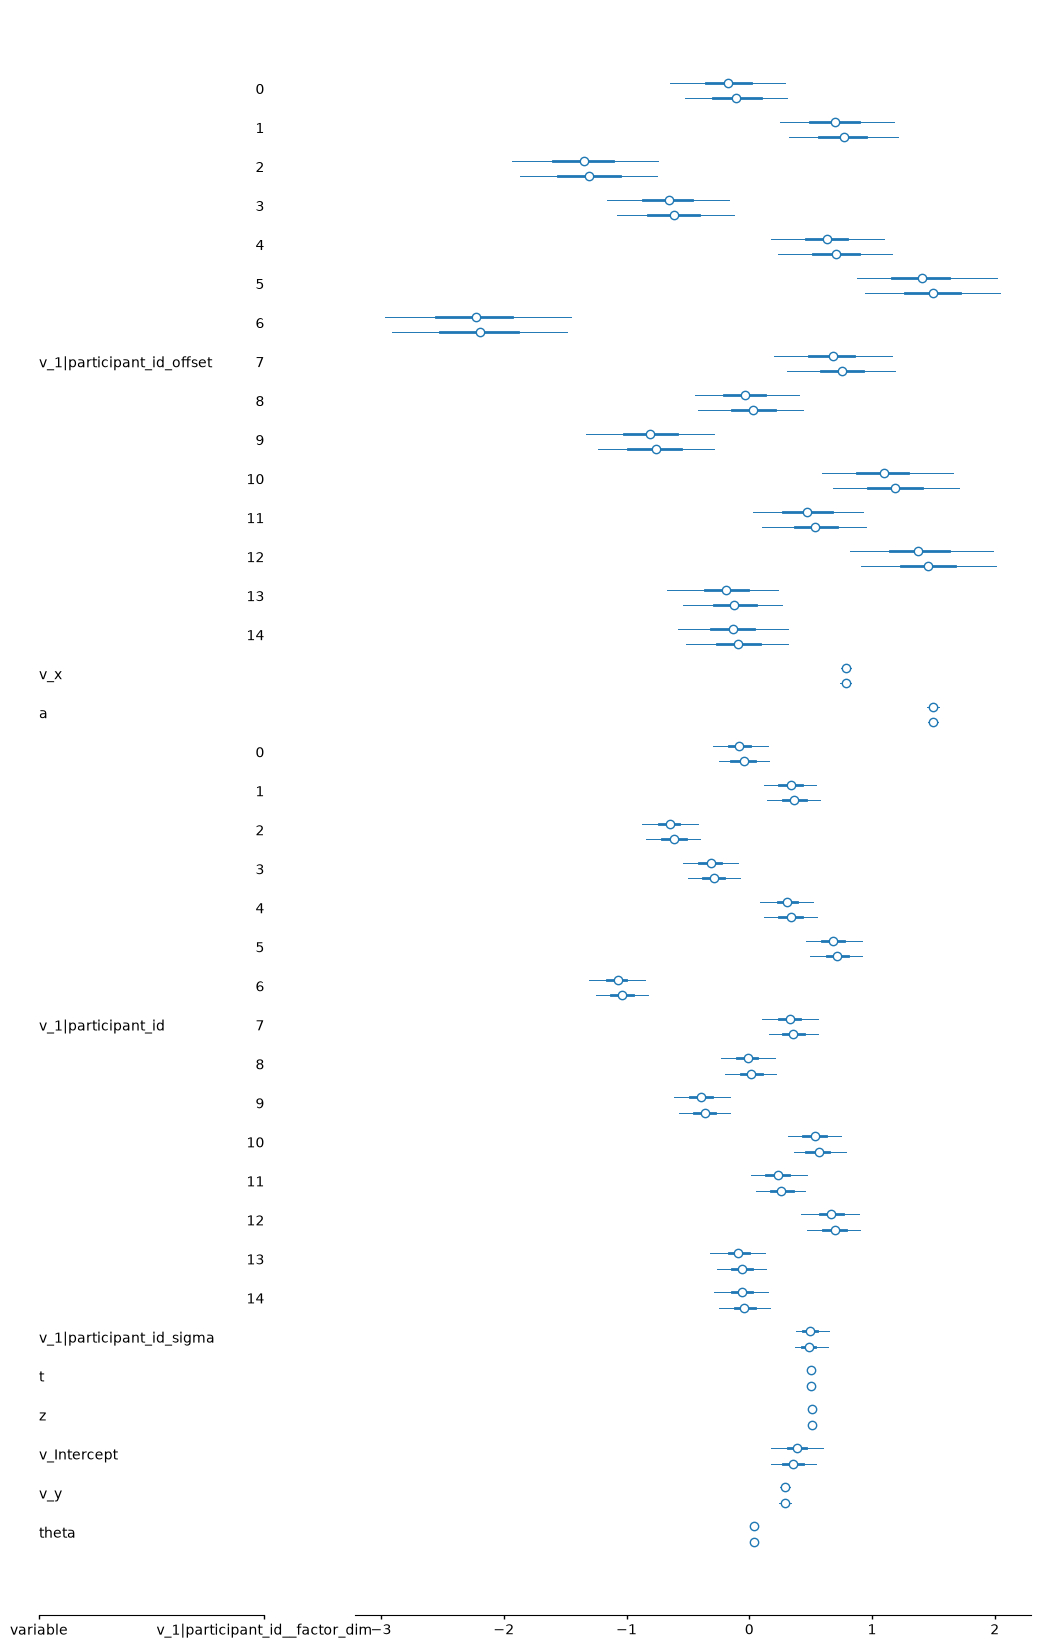

In [74]:
_ = az.plot_forest(infer_data_reg_v_angle_hier, combined=False)

## 4. Validate and compare models

Model comparison asks how well competing models predict the same data while accounting for fit and complexity. It comes after diagnostics and posterior predictive checks because a model with poor sampling behavior or obvious predictive failures is not a strong scientific candidate, even if a comparison table looks favorable. Here the data are generated with `a=1.5`, and we compare three DDMs that fix `a` too low (`1.3`), correctly (`1.5`), or too high (`1.7`).

We use ArviZ's `compare()` function with expected log predictive density from leave-one-out cross-validation (`elpd_loo`). Higher expected predictive accuracy is better, but close differences should be interpreted as uncertainty rather than a hard ranking.

### Data Simulation

In [75]:
# Parameters
param_dict_mod_comp = dict(v=0.5, a=1.5, z=0.5, t=0.2)

# Simulation
dataset_model_comp = hssm.simulate_data(
    model="ddm",
    theta=param_dict_mod_comp,
    size=N_COMPARE_TRIALS,
    random_state=SEEDS["compare_data"],
)

{
    "shape": dataset_model_comp.shape,
    "preview": dataset_model_comp.head(),
}

{'shape': (500, 2),
 'preview':          rt  response
 0  1.586593       1.0
 1  1.909450       1.0
 2  2.402417       1.0
 3  1.193287       1.0
 4  2.234198       1.0}

### Defining the Models

In [76]:
# "under-specified" model — boundary fixed too low
model_model_comp_1 = hssm.HSSM(
    data=dataset_model_comp,
    model="ddm",
    a=1.3,
    initval_jitter=INITVAL_JITTER,
)

Model initialized successfully.


In [77]:
# "correct" model — boundary fixed at the data-generating value
model_model_comp_2 = hssm.HSSM(
    data=dataset_model_comp,
    model="ddm",
    a=1.5,
    initval_jitter=INITVAL_JITTER,
)

Model initialized successfully.


In [78]:
# "over-specified" model — boundary fixed too high
model_model_comp_3 = hssm.HSSM(
    data=dataset_model_comp,
    model="ddm",
    a=1.7,
    initval_jitter=INITVAL_JITTER,
)

Model initialized successfully.


In [79]:
infer_data_model_comp_1 = quiet_call(
    model_model_comp_1.sample,
    sampler="pymc",
    cores=1,
    chains=N_CHAINS,
    draws=N_DRAWS,
    tune=N_TUNE,
    idata_kwargs=dict(
        log_likelihood=True
    ),  # model comparison metrics usually need this!
    mp_ctx="spawn",
    progressbar=PYMC_PROGRESS,
    random_seed=SEEDS["compare_1"],
)

In [80]:
infer_data_model_comp_2 = quiet_call(
    model_model_comp_2.sample,
    sampler="pymc",
    cores=1,
    chains=N_CHAINS,
    draws=N_DRAWS,
    tune=N_TUNE,
    idata_kwargs=dict(
        log_likelihood=True
    ),  # model comparison metrics usually need this!
    mp_ctx="spawn",
    progressbar=PYMC_PROGRESS,
    random_seed=SEEDS["compare_2"],
)

In [81]:
infer_data_model_comp_3 = quiet_call(
    model_model_comp_3.sample,
    sampler="pymc",
    cores=1,
    chains=N_CHAINS,
    draws=N_DRAWS,
    tune=N_TUNE,
    idata_kwargs=dict(
        log_likelihood=True
    ),  # model comparison metrics usually need this!
    mp_ctx="spawn",
    progressbar=PYMC_PROGRESS,
    random_seed=SEEDS["compare_3"],
)

### Compare

In [82]:
compare_data = quiet_call(
    az.compare,
    {
        "a_fixed_1.3(under)": infer_data_model_comp_1,
        "a_fixed_1.5(correct)": infer_data_model_comp_2,
        "a_fixed_1.7(over)": infer_data_model_comp_3,
    },
)

compare_data

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
a_fixed_1.5(correct),0,0.0,0.0,NaN,,,2.9,-1030.0,26.0,0.54
a_fixed_1.7(over),1,-1.0,4.5,0.57,|elpd_diff| < 4,,2.6,-1030.0,25.0,0.46
a_fixed_1.3(under),2,-30.0,5.8,1.00,,,4.3,-1060.0,29.0,0.00


In this controlled example, inspect whether the correctly specified model has the highest expected predictive accuracy and whether its uncertainty overlaps the alternatives. If the ordering differs or estimates are close, report that uncertainty rather than forcing a winner. In applied work, use comparison as one piece of evidence alongside posterior predictive checks and domain knowledge.

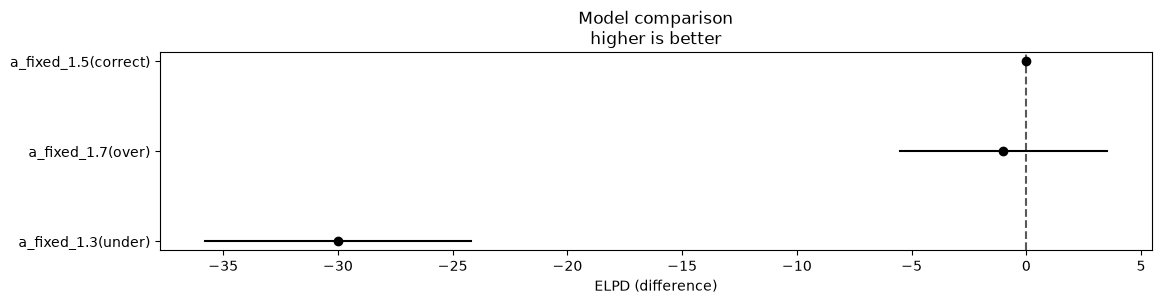

In [83]:
_ = az.plot_compare(compare_data)

The forest plot can explain comparison differences: when `a` is fixed incorrectly, inspect whether other parameters shift to compensate. This is a useful habit after model comparison, regardless of which candidate ranks first in a finite run.

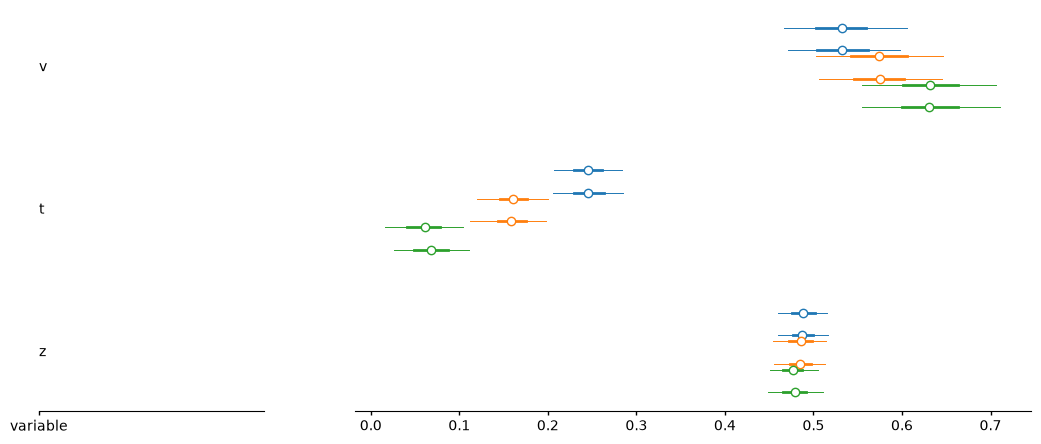

In [84]:
_ = az.plot_forest(
    {
        "a_fixed_1.3(under)": infer_data_model_comp_1,
        "a_fixed_1.5(correct)": infer_data_model_comp_2,
        "a_fixed_1.7(over)": infer_data_model_comp_3,
    }
)

### Simulation and model configuration under the hood

The following optional examples show trial-wise simulation, model discovery, and direct use of `ssm-simulators`. They are useful when you move beyond the introductory DDM workflow.

#### Trial-wise simulation with HSSM

In [85]:
# a changes trial wise
_rng = np.random.default_rng(SEEDS["trialwise"])
a_trialwise = _rng.normal(loc=2, scale=0.3, size=N_ADVANCED_TRIALS)

dataset_a_trialwise = hssm.simulate_data(
    model="ddm",
    theta=dict(
        v=v_true,
        a=a_trialwise,
        z=z_true,
        t=t_true,
    ),
    size=1,
    random_state=SEEDS["trialwise"],
)

dataset_a_trialwise

,rt,response
0,3.034988,1.0
1,1.329756,1.0
2,3.844689,1.0
3,4.416183,1.0
4,1.098635,1.0
...,...,...
995,2.331775,1.0
996,1.140709,-1.0
997,3.308954,1.0
998,4.608150,1.0


HSSM can simulate many supported models. The models available for simulation and the models with packaged likelihood functions are related but not identical; inspect the supported-model list when choosing a model for inference.

In [86]:
hssm.HSSM.supported_models

('ddm',
 'ddm_sdv',
 'full_ddm',
 'angle',
 'levy',
 'ornstein',
 'weibull',
 'race_no_bias_angle_4',
 'ddm_seq2_no_bias',
 'gamma_drift',
 'lba3',
 'lba4',
 'lba2',
 'racing_diffusion_3',
 'poisson_race',
 'softmax_inv_temperature_2',
 'softmax_inv_temperature_3')

The model configuration records parameter names, default likelihoods, bounds, and prior settings. It is useful when you are adapting a built-in model or contributing a new one.

In [87]:
hssm.modelconfig.get_default_model_config("ddm")

{'response': ['rt', 'response'],
 'list_params': ['v', 'a', 'z', 't'],
 'choices': [-1, 1],
 'description': 'The Drift Diffusion Model (DDM)',
 'likelihoods': {'analytical': {'loglik': <function hssm.likelihoods.analytical.logp_ddm(data: numpy.ndarray, v: float, a: float, z: float, t: float, err: float = 1e-15, k_terms: int = 20, epsilon: float = 1e-15) -> numpy.ndarray>,
   'backend': None,
   'bounds': {'v': (-inf, inf),
    'a': (0.0, inf),
    'z': (0.0, 1.0),
    't': (0.0, inf)},
   'default_priors': {'t': {'name': 'HalfNormal', 'sigma': 2.0}},
   'extra_fields': None},
  'approx_differentiable': {'loglik': 'ddm.onnx',
   'backend': 'jax',
   'default_priors': {'t': {'name': 'HalfNormal', 'sigma': 2.0}},
   'bounds': {'v': (-3.0, 3.0),
    'a': (0.3, 2.5),
    'z': (0.0, 1.0),
    't': (0.0, 2.0)},
   'extra_fields': None},
  'blackbox': {'loglik': <function hssm.likelihoods.blackbox.hddm_to_hssm.<locals>.outer(data: numpy.ndarray, *args, **kwargs)>,
   'backend': None,
   'bound

For simulation, two configuration entries are particularly useful:

1. `list_params` gives the parameter order and names expected by the model.
2. `likelihoods` records the available `analytical`, `approx_differentiable`, and `blackbox` likelihood options, together with their bounds and defaults.

#### Direct `ssm-simulators` usage

In [88]:
from ssms.basic_simulators.simulator import simulator

theta_mat = np.zeros((N_ADVANCED_TRIALS, 4))
theta_mat[:, 0] = v_true
theta_mat[:, 1] = a_trialwise
# a changes trial wise
theta_mat[:, 2] = z_true
theta_mat[:, 3] = t_true  # v
sim_out_trialwise = simulator(
    theta=theta_mat,
    model="ddm",
    n_samples=1,
    random_state=SEEDS["trialwise"],
)  # a
dataset_trialwise = pd.DataFrame(
    np.column_stack(
        [sim_out_trialwise["rts"][:, 0], sim_out_trialwise["choices"][:, 0]]
    ),
    columns=["rt", "response"],
)  # z
# simulate data
# Turn into nice dataset
dataset_trialwise  # t  # parameter_matrix  # specify model (many are included in ssms)  # number of samples for each set of parameters  # (plays the role of `size` parameter in `hssm.simulate_data`)

,rt,response
0,3.034988,1.0
1,1.329756,1.0
2,3.844689,1.0
3,4.416183,1.0
4,1.098635,1.0
...,...,...
995,2.331775,1.0
996,1.140709,-1.0
997,3.308954,1.0
998,4.608150,1.0


For most HSSM workflows, `hssm.simulate_data()` is the clearest starting point. Direct `ssm-simulators` access is useful when you need the simulator’s lower-level output or a custom simulation pipeline.

## 5. Optional advanced extensions

The remaining sections show how HSSM connects to the broader computational ecosystem. They are optional for a first analysis, but useful when you need custom simulators, likelihoods, or a lower-level PyMC model. If you are new to HSSM, it is reasonable to stop after model comparison and return here once you need more control.

<div style="text-align: center;">
  <img src="images/pytensor_jax.png" alt="PyTensor and JAX logos" style="height: 120px; width: auto; max-width: 80%;">
</div>

In [89]:
hssm.config.default_model_config["ddm"].keys()

dict_keys(['response', 'list_params', 'choices', 'description', 'likelihoods'])

A model configuration describes its response coding, parameter list, description, and available likelihood definitions. Inspecting it is a practical starting point for advanced customization.

In [90]:
hssm.config.default_model_config["ddm"]["likelihoods"]

{'analytical': {'loglik': <function hssm.likelihoods.analytical.logp_ddm(data: numpy.ndarray, v: float, a: float, z: float, t: float, err: float = 1e-15, k_terms: int = 20, epsilon: float = 1e-15) -> numpy.ndarray>,
  'backend': None,
  'bounds': {'v': (-inf, inf),
   'a': (0.0, inf),
   'z': (0.0, 1.0),
   't': (0.0, inf)},
  'default_priors': {'t': {'name': 'HalfNormal', 'sigma': 2.0}},
  'extra_fields': None},
 'approx_differentiable': {'loglik': 'ddm.onnx',
  'backend': 'jax',
  'default_priors': {'t': {'name': 'HalfNormal', 'sigma': 2.0}},
  'bounds': {'v': (-3.0, 3.0),
   'a': (0.3, 2.5),
   'z': (0.0, 1.0),
   't': (0.0, 2.0)},
  'extra_fields': None},
 'blackbox': {'loglik': <function hssm.likelihoods.blackbox.hddm_to_hssm.<locals>.outer(data: numpy.ndarray, *args, **kwargs)>,
  'backend': None,
  'bounds': {'v': (-inf, inf),
   'a': (0.0, inf),
   'z': (0.0, 1.0),
   't': (0.0, inf)},
  'default_priors': {'t': {'name': 'HalfNormal', 'sigma': 2.0}},
  'extra_fields': None}}

The DDM configuration exposes three likelihood kinds: `analytical`, `approx_differentiable`, and `blackbox`. The kind determines the representation of the likelihood and which samplers are compatible.

In [91]:
hssm.config.default_model_config["ddm"]["likelihoods"]["analytical"]

{'loglik': <function hssm.likelihoods.analytical.logp_ddm(data: numpy.ndarray, v: float, a: float, z: float, t: float, err: float = 1e-15, k_terms: int = 20, epsilon: float = 1e-15) -> numpy.ndarray>,
 'backend': None,
 'bounds': {'v': (-inf, inf),
  'a': (0.0, inf),
  'z': (0.0, 1.0),
  't': (0.0, inf)},
 'default_priors': {'t': {'name': 'HalfNormal', 'sigma': 2.0}},
 'extra_fields': None}

The key entries are `loglik`, `backend`, `bounds`, and `default_priors`. Bounds constrain valid parameter regions, while defaults provide a usable prior specification when one is not supplied explicitly.

An `approx_differentiable` likelihood can be represented by a differentiable approximation, such as a likelihood approximation network. HSSM can evaluate compatible likelihoods through PyTensor or JAX backends.

In [92]:
hssm.config.default_model_config["ddm"]["likelihoods"]["approx_differentiable"]

{'loglik': 'ddm.onnx',
 'backend': 'jax',
 'default_priors': {'t': {'name': 'HalfNormal', 'sigma': 2.0}},
 'bounds': {'v': (-3.0, 3.0),
  'a': (0.3, 2.5),
  'z': (0.0, 1.0),
  't': (0.0, 2.0)},
 'extra_fields': None}

For packaged approximate likelihoods, `loglik` may point to an ONNX model. ONNX is a portable format for neural-network likelihood approximators. The backend determines whether HSSM evaluates the likelihood through PyTensor or JAX, which in turn affects compatible MCMC samplers.

The practical takeaway is that HSSM keeps the user-facing model specification stable while allowing different likelihood representations underneath.

In [93]:
hssm_alternative_model = hssm.HSSM(
    data=dataset,
    model="ddm",
    loglik_kind="approx_differentiable",
    initval_jitter=INITVAL_JITTER,
)

Model initialized successfully.


In [94]:
hssm_alternative_model.loglik_kind

'approx_differentiable'

This model uses an `approx_differentiable` LAN likelihood rather than the `analytical` likelihood used in the first DDM example. The assumed generative model remains the DDM.

In [95]:
infer_data_alternative = quiet_call(
    hssm_alternative_model.sample,
    sampler="pymc",
    cores=1,
    chains=N_CHAINS,
    draws=N_DRAWS,
    tune=N_TUNE,
    idata_kwargs=dict(log_likelihood=False),  # no comparison here
    mp_ctx="spawn",
    progressbar=PYMC_PROGRESS,
    random_seed=SEEDS["alternative"],
)

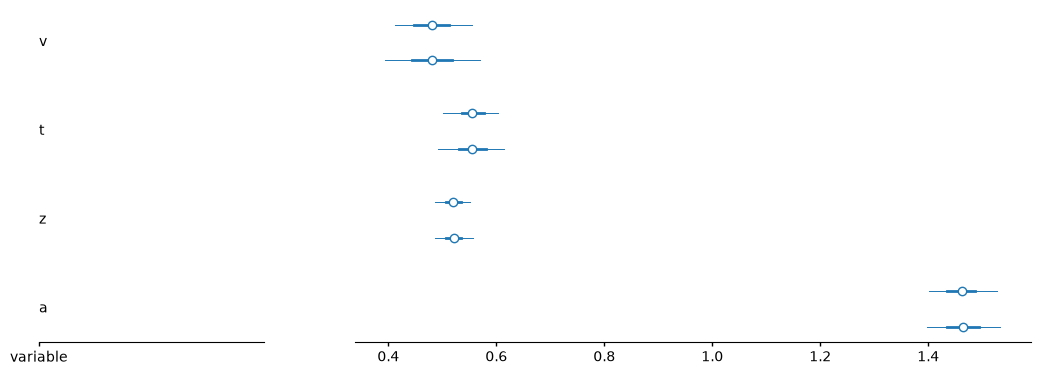

In [96]:
_ = az.plot_forest(infer_data_alternative)

You can also provide a custom likelihood directly. The next section illustrates the non-differentiable `blackbox` case.

### Black-box likelihoods

<div style="text-align: center;">
  <img src="images/blackbox.png" alt="Black-box likelihood concept illustration" style="width: 360px; max-width: 90%; height: auto;">
</div>

A black-box likelihood is a Python callable that returns trial-wise log likelihoods. It is useful when you can evaluate a model numerically but do not have a differentiable likelihood representation.

Because black-box likelihoods are generally non-differentiable, HSSM uses a gradient-free sampling strategy by default. This makes them flexible, but they are usually slower and require especially careful diagnostics.

### Simulating simple dataset from the DDM

As always, let's begin by generating some simple dataset.

In [97]:
# Set parameters
param_dict_blackbox = dict(v=0.5, a=1.5, z=0.5, t=0.5)

# Simulate
dataset_blackbox = hssm.simulate_data(
    model="ddm",
    theta=param_dict_blackbox,
    size=N_ADVANCED_TRIALS,
    random_state=SEEDS["blackbox"],
)

### Define the likelihood

The callable receives the observed data and model parameters, then returns trial-wise log likelihoods. In this demonstration it delegates to a DDM likelihood, but the same interface can wrap an appropriate custom computation.

In [98]:
def my_blackbox_loglik(data, v, a, z, t, err=1e-08):
    """Create a custom blackbox likelihood function."""
    data = data[:, 0] * data[:, 1]
    data_nrows = data.shape[0]
    return hddm_wfpt.wfpt.wiener_logp_array(
        np.float64(data),
        (np.ones(data_nrows) * v).astype(np.float64),
        np.ones(data_nrows) * 0,
        (np.ones(data_nrows) * 2 * a).astype(np.float64),
        (np.ones(data_nrows) * z).astype(np.float64),
        np.ones(data_nrows) * 0,
        (np.ones(data_nrows) * t).astype(np.float64),
        np.ones(data_nrows) * 0,
        err,
        1,
    )  # Our function expects inputs as float64, but they are not guaranteed to  # come in as such --> we type convert

### Define HSSM class with our Blackbox Likelihood

Construct the HSSM model as usual, passing the callable as `loglik` and declaring `loglik_kind="blackbox"`. Bounds remain important because they define the region where the custom likelihood is valid.

In [99]:
blackbox_model = hssm.HSSM(
    data=dataset_blackbox,
    model="ddm",
    loglik=my_blackbox_loglik,
    loglik_kind="blackbox",
    model_config={
        "bounds": {
            "v": (-10.0, 10.0),
            "a": (0.5, 5.0),
            "z": (0.0, 1.0),
        }
    },
    t=bmb.Prior("Uniform", lower=0.0, upper=2.0),
    initval_jitter=INITVAL_JITTER,
)

Model initialized successfully.


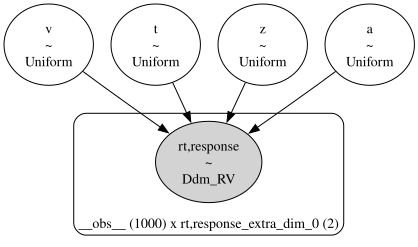

In [100]:
blackbox_model.graph()

In [101]:
sample = quiet_call(
    blackbox_model.sample,
    chains=N_CHAINS,
    cores=1,
    draws=N_DRAWS,
    tune=N_TUNE,
    idata_kwargs={"log_likelihood": False},
    progressbar=PYMC_PROGRESS,
    random_seed=SEEDS["blackbox"],
)

Black-box likelihoods default to a gradient-free Slice sampler. You may choose another suitable PyMC sampler, but gradient-based JAX samplers are not compatible with a non-differentiable likelihood.

### Results

In [102]:
az.summary(sample)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v,0.595,0.033,0.54,0.65,366,468,1.00,0.0017,0.0013
t,0.518,0.023,0.48,0.55,309,419,1.00,0.0013,0.001
z,0.471,0.012,0.45,0.49,317,480,1.01,0.0007,0.00053
a,1.465,0.028,1.4,1.5,327,429,1.00,0.0016,0.0011


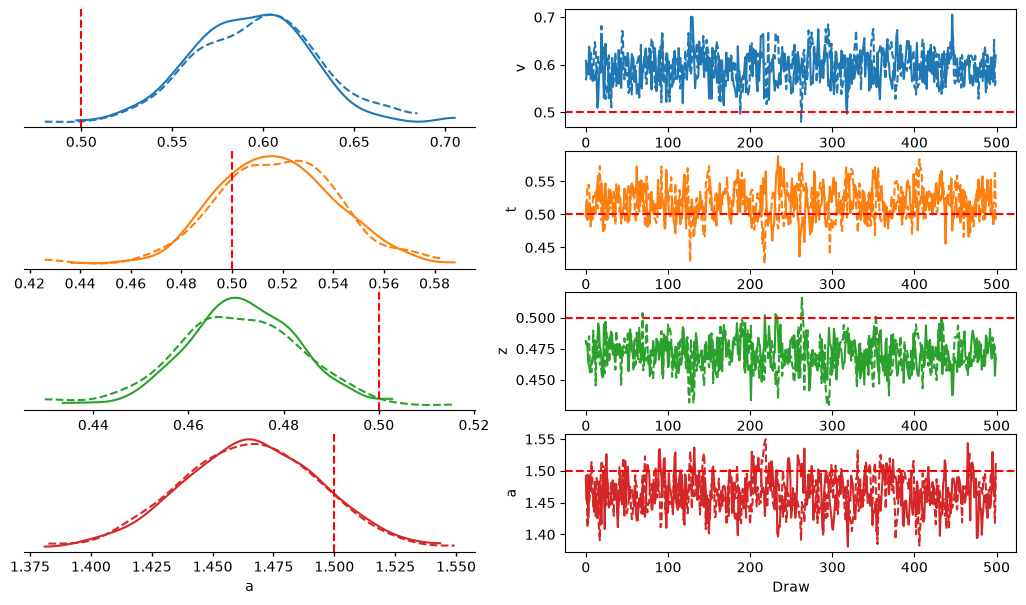

In [103]:
_pc = az.plot_trace_dist(sample)
add_trace_reference_lines(_pc, param_dict_blackbox)

### Low-level PyMC integration

HSSM can also expose sequential-sampling random variables for use inside a custom PyMC model. This is an advanced path for models that require structure beyond the high-level HSSM interface.

See the [low-level PyMC tutorial](https://lnccbrown.github.io/HSSM/tutorials/pymc/) for a focused follow-up example.

In [104]:
# DDM models (the Wiener First-Passage Time distribution)
from hssm.distribution_utils import make_distribution
from hssm.likelihoods import DDM

### Simulate some data

In [105]:
# Simulate
param_dict_pymc = dict(v=0.5, a=1.5, z=0.5, t=0.5)

dataset_pymc = hssm.simulate_data(
    model="ddm",
    theta=param_dict_pymc,
    size=N_ADVANCED_TRIALS,
    random_state=SEEDS["pymc_data"],
)

### Build a custom PyMC Model

We can now use our custom random variable `DDM` directly in a PyMC model.

In [106]:
import pymc as pm

with pm.Model() as ddm_pymc:
    _v = pm.Uniform("v", lower=-10.0, upper=10.0)
    _a = pm.HalfNormal("a", sigma=2.0)
    _z = pm.Uniform("z", lower=0.01, upper=0.99)
    _t = pm.Uniform("t", lower=0.0, upper=0.6)
    ddm = DDM(
        "DDM",
        observed=dataset_pymc[["rt", "response"]].values,
        v=_v,
        a=_a,
        z=_z,
        t=_t,
    )

Let's check the model graph:

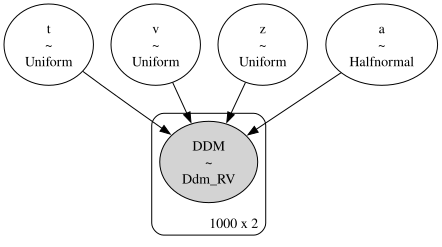

In [107]:
pm.model_to_graphviz(model=ddm_pymc)

The custom PyMC graph resembles the HSSM graph because HSSM builds on the same probabilistic-programming components. You can sample the PyMC model directly and use ArviZ for diagnostics.

In [108]:
with ddm_pymc:
    ddm_pymc_trace = quiet_call(
        pm.sample,
        chains=N_CHAINS,
        cores=1,
        draws=N_DRAWS,
        tune=N_TUNE,
        idata_kwargs={"log_likelihood": False},
        progressbar=PYMC_PROGRESS,
        random_seed=SEEDS["pymc_ddm"],
    )

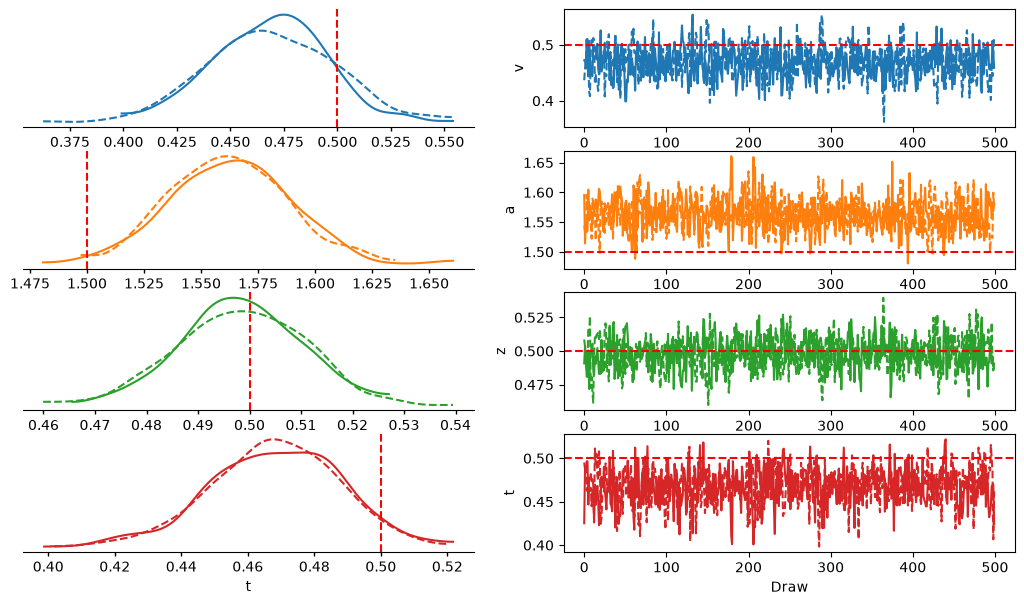

In [109]:
_pc = az.plot_trace_dist(ddm_pymc_trace)
add_trace_reference_lines(_pc, param_dict_pymc)

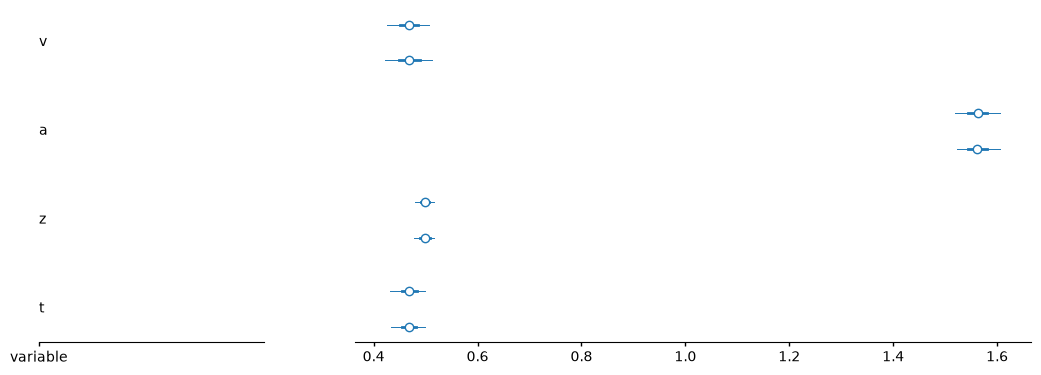

In [110]:
_ = az.plot_forest(ddm_pymc_trace)

#### Alternative models with PyMC

In [111]:
from hssm.distribution_utils import make_likelihood_callable

_angle_loglik = make_likelihood_callable(
    loglik="angle.onnx",
    loglik_kind="approx_differentiable",
    backend="jax",
    params_is_reg=[0, 0, 0, 0, 0],
)
ANGLE = make_distribution(
    "angle",
    loglik=_angle_loglik,
    list_params=hssm.defaults.default_model_config["angle"]["list_params"],
)

The `params_is_reg` vector identifies which likelihood inputs vary trial by trial, as happens when a parameter is produced by a regression formula.

In [112]:
with pm.Model() as angle_pymc:
    _v = pm.Uniform("v", lower=-10.0, upper=10.0)
    _a = pm.Uniform("a", lower=0.5, upper=2.5)
    _z = pm.Uniform("z", lower=0.01, upper=0.99)
    _t = pm.Uniform("t", lower=0.0, upper=0.6)
    _theta = pm.Uniform("theta", lower=-0.1, upper=1.0)
    _angle = ANGLE(
        "ANGLE",
        v=_v,
        a=_a,
        z=_z,
        t=_t,
        theta=_theta,
        observed=dataset_pymc[["rt", "response"]].values,
    )

In [113]:
with angle_pymc:
    idata_object = quiet_call(
        pm.sample,
        nuts_sampler="numpyro",
        chains=N_CHAINS,
        cores=1,
        draws=N_DRAWS,
        tune=N_TUNE,
        idata_kwargs={"log_likelihood": False},
        progressbar=EXTERNAL_PROGRESS,
        random_seed=SEEDS["pymc_angle"],
    )

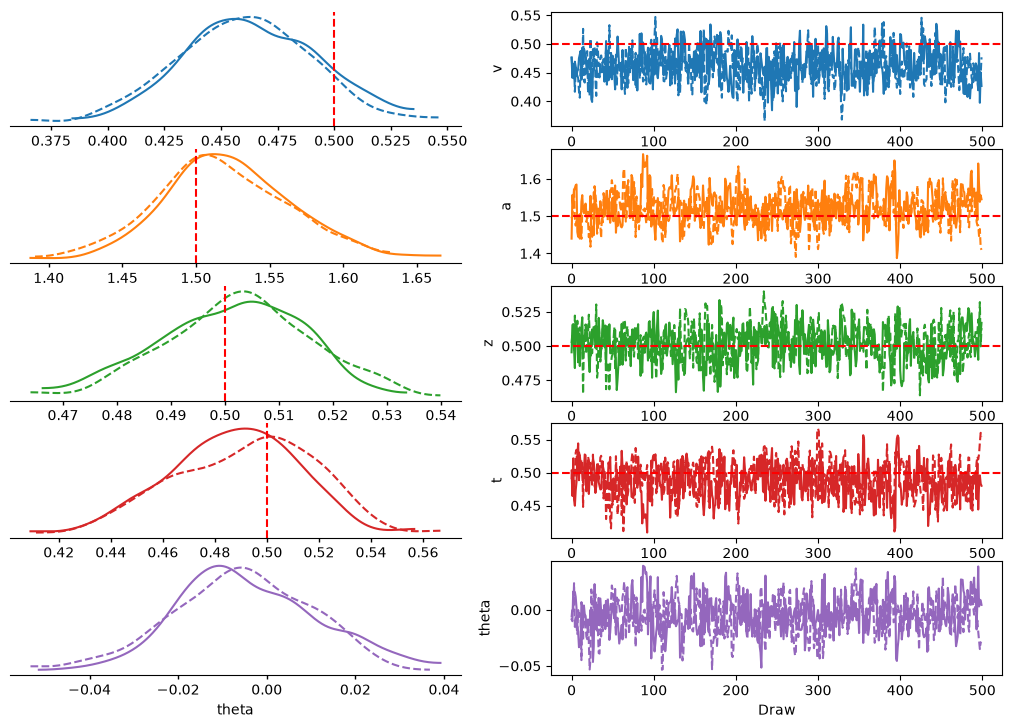

In [114]:
_pc = az.plot_trace_dist(idata_object)
add_trace_reference_lines(_pc, param_dict_pymc)

#### Regression directly in PyMC

In [115]:
from typing import Optional

def make_params_is_reg_vec(
    reg_parameters: Optional[list] = None, parameter_names: Optional[list] = None
):
    """Make a list of Trues and Falses to indicate which parameters are vectors."""
    if (not isinstance(reg_parameters, list)) or (
        not isinstance(parameter_names, list)
    ):
        raise ValueError("Both reg_parameters and parameter_names should be lists")

    bool_list = [0] * len(parameter_names)
    for param in reg_parameters:
        bool_list[parameter_names.index(param)] = 1
    return bool_list

In [116]:
v_intercept_pymc_reg = 0.3
_rng = np.random.default_rng(SEEDS["pymc_reg_data"])
x_pymc_reg = _rng.uniform(-1, 1, size=N_ADVANCED_TRIALS)
v_x_pymc_reg = 0.8
y_pymc_reg = _rng.uniform(-1, 1, size=N_ADVANCED_TRIALS)
v_y_pymc_reg = 0.3
v_pymc_reg = (
    v_intercept_pymc_reg + v_x_pymc_reg * x_pymc_reg + v_y_pymc_reg * y_pymc_reg
)
param_dict_pymc_reg = dict(
    v_Intercept=v_intercept_pymc_reg,
    v_x=v_x_pymc_reg,
    v_y=v_y_pymc_reg,
    v=v_pymc_reg,
    a=1.5,
    z=0.5,
    t=0.1,
    theta=0.0,
)
pymc_reg_data = hssm.simulate_data(
    model="ddm",
    theta=param_dict_pymc_reg,
    size=1,
    random_state=SEEDS["pymc_reg_data"],
)
pymc_reg_data["x"] = x_pymc_reg
pymc_reg_data["y"] = y_pymc_reg
bool_param_reg = make_params_is_reg_vec(
    reg_parameters=["v"],
    parameter_names=hssm.defaults.default_model_config["angle"]["list_params"],
)
_angle_loglik = make_likelihood_callable(
    loglik="angle.onnx",
    loglik_kind="approx_differentiable",
    backend="jax",
    params_is_reg=bool_param_reg,
)
ANGLE_1 = make_distribution(
    "angle",
    loglik=_angle_loglik,
    list_params=hssm.defaults.default_model_config["angle"]["list_params"],
)

In [117]:
import pytensor.tensor as pt

with pm.Model(
    coords={
        "idx": pymc_reg_data.index,
        "resp": ["rt", "response"],
        "features": ["x", "y"],
    }
) as pymc_model_reg:
    x_ = pm.Data("x", pymc_reg_data["x"].values, dims="idx")
    y_ = pm.Data("y", pymc_reg_data["y"].values, dims="idx")
    obs = pm.Data(
        "obs", pymc_reg_data[["rt", "response"]].values, dims=("idx", "resp")
    )
    _a = pm.Uniform("a", lower=0.5, upper=2.5)
    _z = pm.Uniform("z", lower=0.01, upper=0.99)
    _t = pm.Uniform("t", lower=0.0, upper=0.6)
    _theta = pm.Uniform("theta", lower=-0.1, upper=1.0)
    v_Intercept = pm.Uniform("v_Intercept", lower=-3, upper=3)
    v_betas = pm.Normal("v_beta", mu=[0, 0], sigma=0.5, dims="features")
    _v = pm.Deterministic(
        "v", v_Intercept + pt.stack([x_, y_], axis=1) @ v_betas, dims="idx"
    )
    _angle = ANGLE_1(
        "angle",
        v=_v.squeeze(),
        a=_a,
        z=_z,
        t=_t,
        theta=_theta,
        observed=obs,
        dims=("idx", "resp"),
    )

In [118]:
with pymc_model_reg:
    idata_pymc_reg = quiet_call(
        pm.sample,
        nuts_sampler="numpyro",
        chains=N_CHAINS,
        cores=1,
        draws=N_DRAWS,
        tune=N_TUNE,
        idata_kwargs={"log_likelihood": False},
        progressbar=EXTERNAL_PROGRESS,
        random_seed=SEEDS["pymc_reg"],
    )

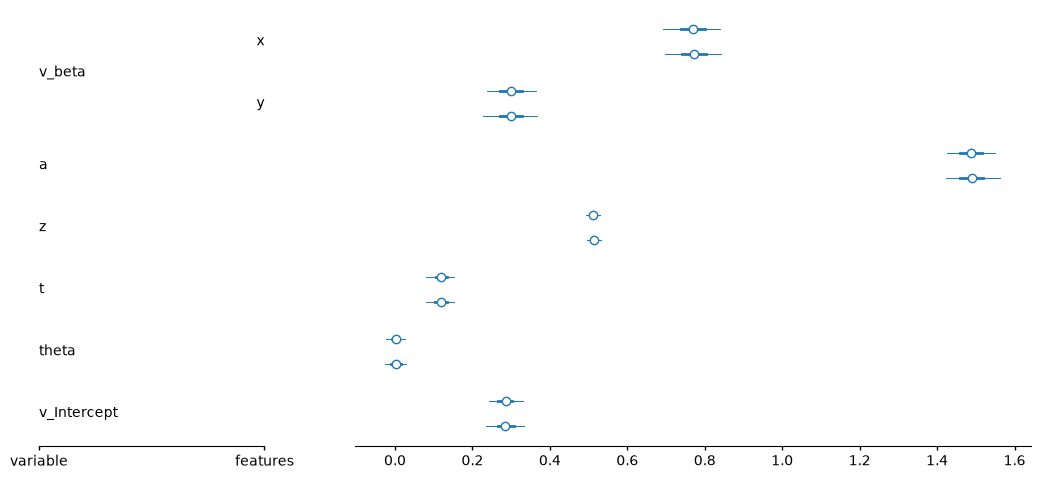

In [119]:
_ = az.plot_forest(idata_pymc_reg, var_names=["~v"])

## Conclusion and further resources

You have now followed the core HSSM workflow: simulate or load data, define a model, sample the posterior, diagnose MCMC behavior, check predictions, and compare alternatives. From there, use the following resources according to your next question.

### Learn more

- **HSSM foundations:** [documentation](https://lnccbrown.github.io/HSSM/), [Quickstart](https://lnccbrown.github.io/HSSM/getting_started/getting_started/), and [hierarchical modeling](https://lnccbrown.github.io/HSSM/getting_started/hierarchical_modeling/)
- **Applied workflows:** [plotting](https://lnccbrown.github.io/HSSM/tutorials/plotting/) and the [Scientific Workflow tutorial](https://lnccbrown.github.io/HSSM/tutorials/scientific_workflow_hssm/)
- **Ecosystem tools:** [PyMC](https://www.pymc.io/), [Bambi](https://bambinos.github.io/bambi/), [ArviZ](https://python.arviz.org/en/stable/user_guide/getting_started.html), and [ssm-simulators](https://github.com/lnccbrown/ssm-simulators)
- **Community and contributions:** [GitHub](https://github.com/lnccbrown/HSSM), [Discussions](https://github.com/lnccbrown/HSSM/discussions), and the [contribution guide](https://github.com/lnccbrown/HSSM/blob/main/docs/CONTRIBUTING.md)

As you extend an analysis, keep returning to the same cycle: state the scientific question, make the model assumptions explicit, check sampler diagnostics and predictions, and communicate uncertainty alongside point estimates.

### A note on tutorial scale

The examples use modest sampling settings so the notebook is practical to run. Before drawing scientific conclusions, increase the number of chains, draws, and tuning iterations; inspect convergence diagnostics; and perform model checks tailored to your data.